In [61]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import statsmodels.api as sm
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.preprocessing import StandardScaler
import prince
import os
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB

In [4]:
#!conda install -c conda-forge jupyterlab numpy pandas scipy matplotlib seaborn prince -y
#!pip install xgboost

In [62]:
dataset_path = f"../dataset/McGill_Pain_Questionnaire_CLAUDE.csv"
df = pd.read_csv(dataset_path)
rename_columns = {
    'ID': 'ID',
    'Sex': 'Sex',
    'Age': 'Age',
    'BPM': 'BPM',
    'total_pain_score': 'Total_Pain_Score',
    'temporal': 'Temporal',
    'temporal_score': 'Temporal_Score',
    'spatial': 'Spatial',
    'spatial_score': 'Spatial_Score',
    'punctate': 'Punctate_Pressure',
    'Punctate_Pressure_Score': 'Punctate_Pressure_Score',  # se manca va rimossa
    'punctate_score': 'Punctate_Pressure_Score',
    'incisive': 'Incisive_Pressure',
    'incisive_score': 'Incisive_Pressure_Score',
    'constrictive': 'Constrictive_Pressure',
    'constrictive_score': 'Constrictive_Pressure_Score',
    'traction': 'Traction_Pressure',
    'Traction_Pressure_Score': 'Traction_Pressure_Score',
    'traction_score': 'Traction_Pressure_Score',
    'thermal': 'Thermal',
    'thermal_score': 'Thermal_Score',
    'brightness': 'Brightness',
    'brightness_score': 'Brightness_Score',
    'dullness': 'Dullness',
    'dullness_score': 'Dullness_Score',
    'sensory_misc': 'Sensory_Misc',
    'sensory_misc_score': 'Sensory_Misc_Score',
    'tension': 'Tension',
    'tension_score': 'Tension_Score',
    'autonomic': 'Autonomic',
    'autonomic_score': 'Autonomic_Score',
    'fear': 'Fear',
    'fear_score': 'Fear_Score',
    'punishment': 'Punishment',
    'punishment_score': 'Punishment_Score',
    'affective_evaluative_sensory': 'Affective_Eval_Sensory',
    'Affective_Eval_Sensory_Score': 'Affective_Eval_Sensory_Score',
    'affective_evaluative_sensory_score': 'Affective_Eval_Sensory_Score',
    'evaluative': 'Evaluative',
    'evaluative_score': 'Evaluative_Score',
    'sensory': 'Sensory',
    'sensory_score': 'Sensory_Score',
    'sensory_2': 'Sensory2',
    'sensory_2_score': 'Sensory2_Score',
    'sensory_3': 'Sensory3',
    'sensory_3_score': 'Sensory3_Score',
    'affective': 'Affective',
    'affective_score': 'Affective_Score',
    'pain_pattern': 'Pain_Pattern',
    'factor_liquor': 'liquor',
    'factor_stimulants_such_as_coffee': 'stimulants',
    'factor_eating': 'eating',
    'factor_heat': 'heat',
    'factor_cold': 'cold',
    'factor_damp': 'damp',
    'factor_weather_changes': 'weather_changes',
    'factor_massage_or_use_of_a_vibrator': 'massage',
    'factor_pressure': 'pressure',
    'factor_no_movement': 'no_movement',
    'factor_movement': 'movement',
    'factor_sleep_or_rest': 'sleep',
    'factor_lying_down': 'lying_down',
    'factor_distraction_TV_reading_etc': 'distraction',
    'factor_urination_or_defecation': 'urination',
    'factor_tension': 'tension',
    'factor_bright_lights': 'bright_lights',
    'factor_loud_noises': 'loud_noises',
    'factor_going_to_work': 'work',
    'factor_intercourse': 'intercourse',
    'factor_mild_exercise': 'mild_exercise',
    'factor_fatigue': 'fatigue',
    'pain_right_now': 'Pain_Now',
    'pain_right_now_score': 'Pain_Now_Score',
    'pain_at_worst': 'Pain_Worst',
    'pain_at_worst_score': 'Pain_Worst_Score',
    'pain_at_least': 'Pain_Least',
    'pain_at_least_score': 'Pain_Least_Score',
    'worst_toothache': 'Worst_Toothache',
    'worst_toothache_score': 'Worst_Toothache_Score',
    'worst_headache': 'Worst_Headache',
    'worst_headache_score': 'Worst_Headache_Score',
    'worst_stomachache': 'Worst_Stomachache',
    'worst_stomachache_score': 'Worst_Stomachache_Score',
    'interference_Activity': 'Activity',
    'interference_Enjoy': 'Enjoy',
    'interference_Mood': 'Mood',
    'interference_Relate': 'Relate',
    'interference_Sleep': 'Sleep',
    'interference_Walk': 'Walk',
    'interference_Work': 'Work',
    'pain_type': 'pain_type',
    'surgery_site': 'surgery_site',
    'tumor_sitology': 'tumor_sitology',
    'irradiation_site': 'irradiation_site',
    'osteoarthropathy': 'osteoarthropathy',
    'pain_projection': 'pain_projection'
}


df.rename(columns=rename_columns, inplace=True)
desired_scores = ['Temporal_Score', 'Spatial_Score', 
       'Punctate_Pressure_Score', 
       'Incisive_Pressure_Score', 
       'Constrictive_Pressure_Score', 
       'Traction_Pressure_Score',  'Thermal_Score', 
       'Brightness_Score',  'Dullness_Score', 
       'Sensory_Misc_Score', 'Tension_Score',
       'Autonomic_Score',  'Fear_Score', 
       'Punishment_Score', 
       'Affective_Eval_Sensory_Score', 'Evaluative_Score',
      'Sensory_Score',  'Sensory2_Score', 
       'Sensory3_Score',  'Affective_Score'
    
]
df['PRI'] = df[desired_scores].sum(axis=1)

In [63]:
df.columns

Index(['ID', 'Sex', 'Age', 'BPM', 'Sensory', 'Sensory_Score', 'Fear',
       'Fear_Score', 'Sensory_Misc', 'Sensory_Misc_Score', 'Brightness',
       'Brightness_Score', 'Affective', 'Affective_Score', 'Thermal',
       'Thermal_Score', 'Traction_Pressure', 'Traction_Pressure_Score',
       'Tension', 'Tension_Score', 'Evaluative', 'Evaluative_Score',
       'Dullness', 'Dullness_Score', 'Autonomic', 'Autonomic_Score',
       'Sensory3', 'Sensory3_Score', 'Spatial', 'Spatial_Score',
       'Affective_Eval_Sensory', 'Affective_Eval_Sensory_Score', 'Temporal',
       'Temporal_Score', 'Punishment', 'Punishment_Score', 'Punctate_Pressure',
       'Punctate_Pressure_Score', 'Sensory2', 'Sensory2_Score',
       'Incisive_Pressure', 'Incisive_Pressure_Score', 'Constrictive_Pressure',
       'Constrictive_Pressure_Score', 'Pain_Pattern', 'liquor', 'stimulants',
       'eating', 'heat', 'cold', 'damp', 'weather_changes', 'massage',
       'pressure', 'no_movement', 'movement', 'sleep', 'lying_

# ACM

         0         1         2         3         4         5         6   \
0  0.173658  0.138829  0.055721  0.261258  0.057364 -0.019442  0.085315   
1 -0.123431  0.194839 -0.041336 -0.038180 -0.325239  0.073243  0.047470   
2  0.012590  0.103121  0.192714 -0.051179 -0.297429 -0.029371 -0.239828   
3  0.230734  0.097661  0.250816  0.416099 -0.269898  0.116298 -0.006822   
4  0.150034 -0.333431 -0.018977  0.000805 -0.217012 -0.024364  0.003290   

         7         8         9         10        11        12        13  \
0  0.235848 -0.177850  0.030473 -0.218407 -0.267162 -0.230551 -0.048446   
1 -0.020802  0.012280  0.044910  0.113244  0.095043  0.100692  0.190747   
2  0.184602 -0.196181  0.050905  0.141904  0.025709 -0.134604 -0.264493   
3 -0.121789  0.264203  0.023801  0.141426 -0.289895  0.110089 -0.024180   
4 -0.025164  0.033361 -0.090580 -0.259094  0.452223  0.138391  0.142563   

         14  
0 -0.326554  
1  0.310161  
2 -0.120597  
3  0.123796  
4  0.181220  


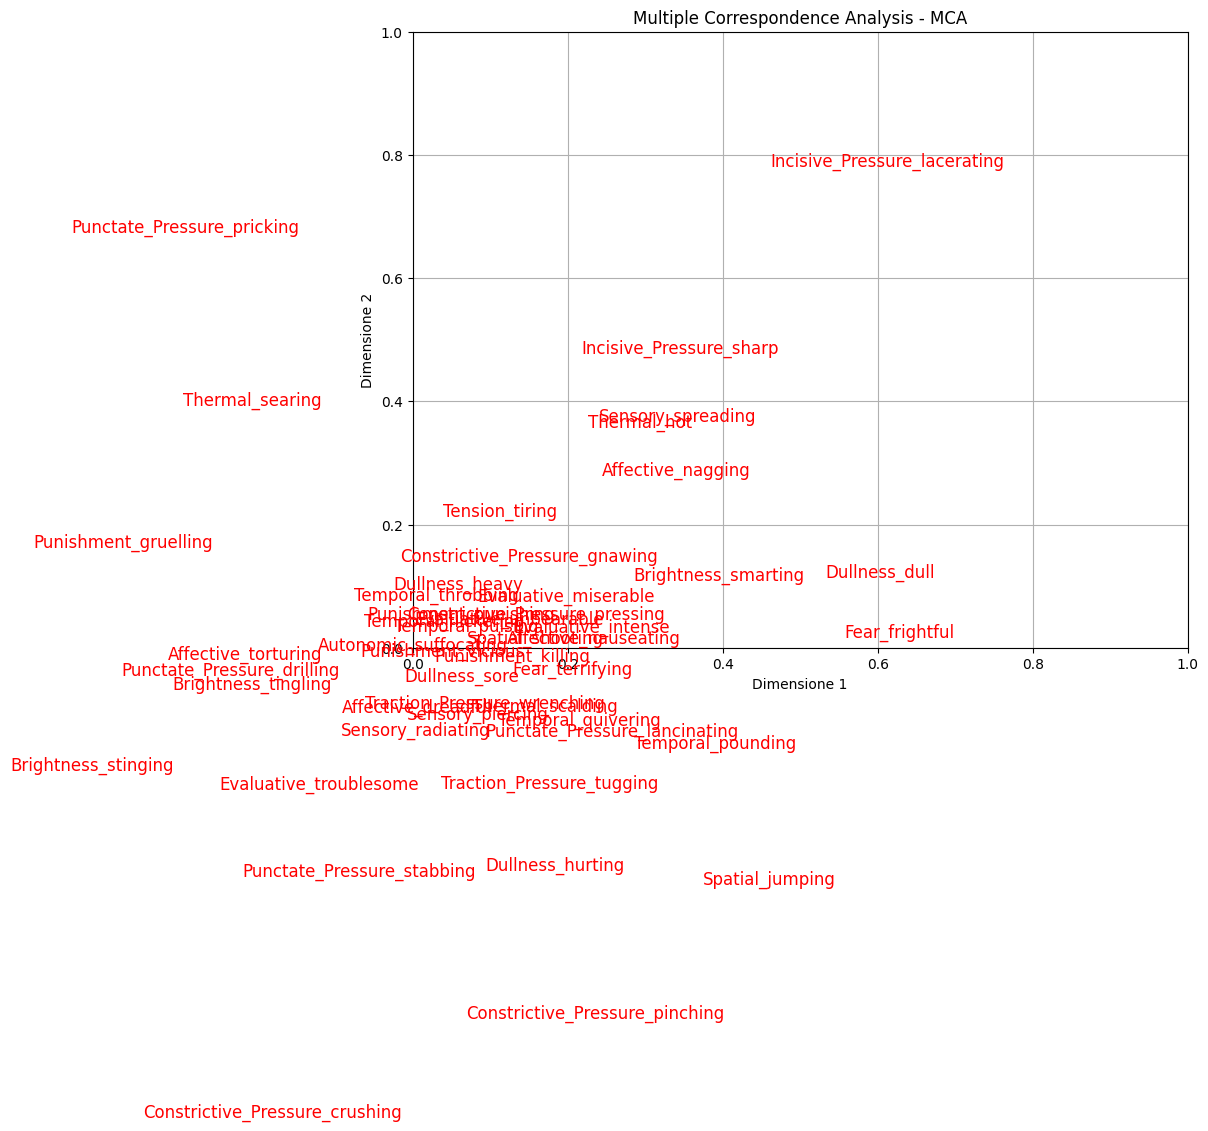

In [6]:
import prince
df_encoded = pd.get_dummies(df[['Temporal', 'Spatial',  'Punctate_Pressure',  'Incisive_Pressure',  'Constrictive_Pressure', 
                                'Traction_Pressure',  'Thermal', 'Brightness',  'Dullness',   'Tension',  'Autonomic',  
                                'Fear', 'Punishment',   'Evaluative',  'Sensory', 'Affective']], drop_first=True)  

mca = prince.MCA(n_components=15, engine='sklearn')
mca = mca.fit(df_encoded)
mca_coordinates = mca.transform(df_encoded)
print(mca_coordinates.head())
variables_coordinates = mca.column_coordinates(df_encoded)
plt.figure(figsize=(10, 8))
#plt.scatter(mca_coordinates[0], mca_coordinates[1], alpha=0.5, color='blue')
plt.title('Multiple Correspondence Analysis - MCA')
plt.xlabel('Dimensione 1')
plt.ylabel('Dimensione 2')
for i in range(min(variables_coordinates.shape[0], df_encoded.shape[1])):
    plt.text(variables_coordinates.iloc[i, 0], variables_coordinates.iloc[i, 1], 
             df_encoded.columns[i], color='red', fontsize=12)
plt.grid(True)
plt.show()

In [7]:
mca.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.040,4.03%,4.03%
1,0.039,3.88%,7.92%
2,0.038,3.84%,11.76%
3,0.038,3.82%,15.58%
4,0.036,3.58%,19.16%
5,0.035,3.49%,22.65%
6,0.034,3.44%,26.08%
7,0.034,3.35%,29.43%
8,0.032,3.24%,32.67%


AttributeError: Rectangle.set() got an unexpected keyword argument 'legend'

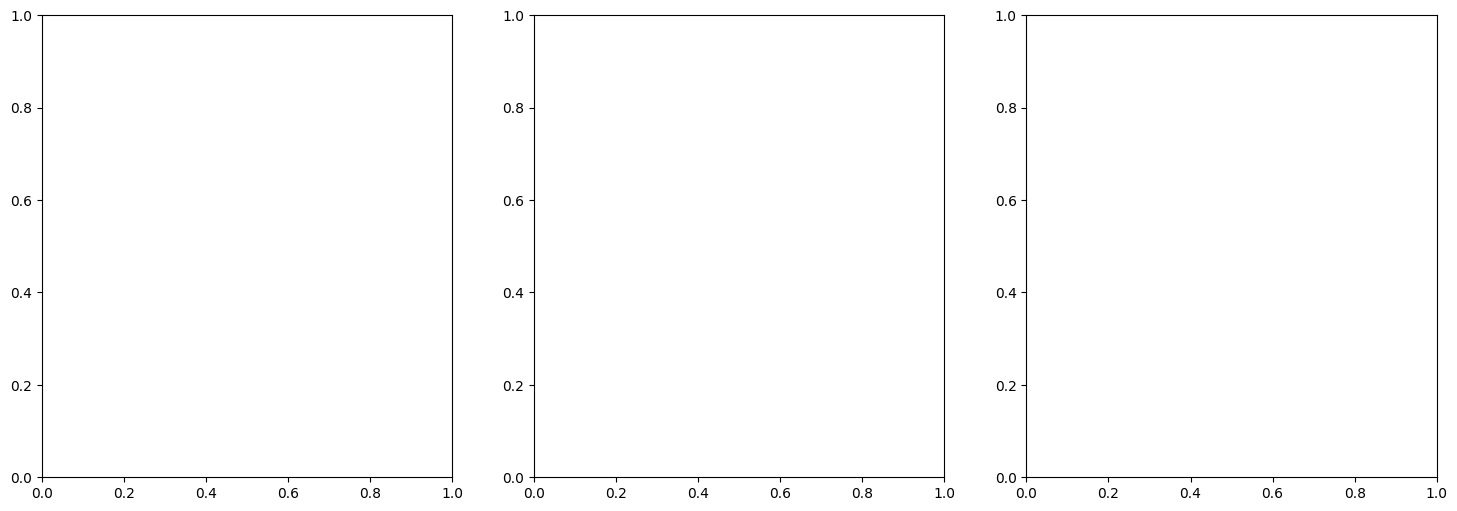

In [8]:
contributions = mca.column_contributions_

top_contributions = contributions.iloc[:, :3]

top_contributions_1 = top_contributions.iloc[:, 0].sort_values(ascending=False).head(15)
top_contributions_2 = top_contributions.iloc[:, 1].sort_values(ascending=False).head(15)
top_contributions_3 = top_contributions.iloc[:, 2].sort_values(ascending=False).head(15)

top_contributions_1 = contributions.iloc[:, 0].sort_values(ascending=False).head(15)
top_contributions_2 = contributions.iloc[:, 1].sort_values(ascending=False).head(15)
top_contributions_3 = contributions.iloc[:, 2].sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(
    x=top_contributions_1.values,
    y=top_contributions_1.index,
    hue=top_contributions_1.index,
    ax=axes[0],
    palette='Blues_d',
    legend=False
)
axes[0].set_title('Dimensione 1: Contributi', fontsize=14)
axes[0].set_xlabel('Contributo', fontsize=12)
axes[0].set_ylabel('Variabili', fontsize=12)

sns.barplot(x=top_contributions_2.values, y=top_contributions_2.index, ax=axes[1], palette='Greens_d')
axes[1].set_title('Dimensione 2: Contributi', fontsize=14)
axes[1].set_xlabel('Contributo', fontsize=12)
axes[1].set_ylabel('Variabili', fontsize=12)

sns.barplot(x=top_contributions_3.values, y=top_contributions_3.index, ax=axes[2], palette='Reds_d')
axes[2].set_title('Dimensione 3: Contributi', fontsize=14)
axes[2].set_xlabel('Contributo', fontsize=12)
axes[2].set_ylabel('Variabili', fontsize=12)

plt.tight_layout()
plt.show()

# Scoring 1 : tre fasce

In [9]:
df['scoring_1'] = df['PRI'].apply(lambda x: 1 if x < 26 else (2 if x <= 46 else 3))
df['scoring_1'] = df['scoring_1'].astype('category')
df['Sex n'] = df['Sex'].apply(lambda x: 0 if x=='F' else 1)

In [10]:
df['scoring_1'].value_counts()

scoring_1
3    258
2    138
1    104
Name: count, dtype: int64

In [11]:
table = pd.crosstab(df['scoring_1'], df['Sex'])
chi2, p, dof, expected = stats.chi2_contingency(table)
print("Chi-quadro:", chi2, "p-value:", p)


group1 = df[df['scoring_1'] == 1]['Age']
group2 = df[df['scoring_1'] == 2]['Age']
group3 = df[df['scoring_1'] == 3]['Age']
t_stat_12, p_value_12 = stats.ttest_ind(group1, group2, equal_var=False)
print("T-test 1 vs 2: statistic:", t_stat_12, "p-value:", p_value_12)
t_stat_13, p_value_13 = stats.ttest_ind(group1, group3, equal_var=False)
print("T-test 1 vs 3: statistic:", t_stat_13, "p-value:", p_value_13)
t_stat_23, p_value_23 = stats.ttest_ind(group2, group3, equal_var=False)
print("T-test 2 vs 3: statistic:", t_stat_23, "p-value:", p_value_23)

Chi-quadro: 5.130586108746573 p-value: 0.07689664324194369
T-test 1 vs 2: statistic: -0.027600098273798314 p-value: 0.9780060651586048
T-test 1 vs 3: statistic: -0.6831490282917986 p-value: 0.49536838111566384
T-test 2 vs 3: statistic: -0.7256710006764298 p-value: 0.4686576320319378


In [12]:
table_sex = pd.crosstab(df['scoring_1'], df['Sex'], margins=True)
table_sex_percent = table_sex.div(table_sex.loc['All'], axis=1) * 100  # Percentuali per colonna

age_stats = df.groupby('scoring_1')['Age'].agg(['count', 'mean', 'std', 'median', 'min', 'max'])
age_stats['IQR'] = df.groupby('scoring_1')['Age'].quantile(0.75) - df.groupby('scoring_1')['Age'].quantile(0.25)

chi2, p, dof, expected = stats.chi2_contingency(table_sex.iloc[:-1, :-1])  # Rimuoviamo la riga 'All' per il test

group1 = df[df['scoring_1'] == 1]['Age']
group2 = df[df['scoring_1'] == 2]['Age']
group3 = df[df['scoring_1'] == 3]['Age']
t_stat_12, p_value_12 = stats.ttest_ind(group1, group2, equal_var=False)
t_stat_13, p_value_13 = stats.ttest_ind(group1, group3, equal_var=False)
t_stat_23, p_value_23 = stats.ttest_ind(group2, group3, equal_var=False)

summary_table = pd.DataFrame({
    'Scoring Group': [1, 2, 3],
    'N (Totale)': age_stats['count'].values,
    'Età Media (SD)': [f"{m:.1f} ({s:.1f})" for m, s in zip(age_stats['mean'], age_stats['std'])],
    'Mediana (IQR)': [f"{med:.1f} ({iqr:.1f})" for med, iqr in zip(age_stats['median'], age_stats['IQR'])],
    'Maschi (%)': [f"{table_sex_percent.loc[i, 'M']:.1f}%" for i in range(1, 4)],
    'Femmine (%)': [f"{table_sex_percent.loc[i, 'F']:.1f}%" for i in range(1, 4)]
})

print(summary_table.to_string(index=False))
print(f"Chi-quadro per il sesso tra i gruppi: χ² = {chi2:.2f}, p-value = {p:.3f}")
print(f"T-test età tra 1 e 2: t = {t_stat_12:.2f}, p-value = {p_value_12:.3f}")
print(f"T-test età tra 1 e 3: t = {t_stat_13:.2f}, p-value = {p_value_13:.3f}")
print(f"T-test età tra 2 e 3: t = {t_stat_23:.2f}, p-value = {p_value_23:.3f}")


 Scoring Group  N (Totale) Età Media (SD) Mediana (IQR) Maschi (%) Femmine (%)
             1         104    49.0 (19.0)   50.5 (36.0)      17.5%       23.6%
             2         138    49.1 (18.7)   49.0 (30.8)      31.9%       24.0%
             3         258    50.5 (18.3)   51.5 (32.0)      50.7%       52.4%
Chi-quadro per il sesso tra i gruppi: χ² = 5.13, p-value = 0.077
T-test età tra 1 e 2: t = -0.03, p-value = 0.978
T-test età tra 1 e 3: t = -0.68, p-value = 0.495
T-test età tra 2 e 3: t = -0.73, p-value = 0.469


/var/folders/v4/mmjnlvt146z3mggjxb3zm4b40000gn/T/ipykernel_1638/919625546.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats = df.groupby('scoring_1')['Age'].agg(['count', 'mean', 'std', 'median', 'min', 'max'])
/var/folders/v4/mmjnlvt146z3mggjxb3zm4b40000gn/T/ipykernel_1638/919625546.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats['IQR'] = df.groupby('scoring_1')['Age'].quantile(0.75) - df.groupby('scoring_1')['Age'].quantile(0.25)


Si crea un modello logistico con tutte le variabili. 

In [21]:
model_dir = "scoring_1 - model , claude"
os.makedirs(model_dir, exist_ok=True)

X = df[['Age', 'Sex n','BPM','Temporal_Score', 'Spatial_Score', 
       'Punctate_Pressure_Score', 
       'Incisive_Pressure_Score', 
       'Constrictive_Pressure_Score', 
       'Traction_Pressure_Score',  'Thermal_Score', 
       'Brightness_Score',  'Dullness_Score', 
       'Sensory_Misc_Score', 'Tension_Score',
       'Autonomic_Score',  'Fear_Score', 
       'Punishment_Score', 
       'Affective_Eval_Sensory_Score', 'Evaluative_Score',
      'Sensory_Score',  'Sensory2_Score', 
       'Sensory3_Score',  'Affective_Score' ]]

y = df['scoring_1'].astype(int) - 1  

In [22]:
y

0      0
1      2
2      2
3      1
4      1
      ..
495    2
496    1
497    1
498    2
499    0
Name: scoring_1, Length: 500, dtype: int64

In [23]:
import inspect
from sklearn.linear_model import LogisticRegression

print(inspect.signature(LogisticRegression))

(penalty='l2', *, dual=False, tol=0.0001, C=1.0, fit_intercept=True, intercept_scaling=1, class_weight=None, random_state=None, solver='lbfgs', max_iter=100, multi_class='deprecated', verbose=0, warm_start=False, n_jobs=None, l1_ratio=None)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "SVM": SVC(),
    "XGBoost": XGBClassifier( eval_metric='logloss'),
    "Bagging": BaggingClassifier(),
    "CART": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naïve Bayes": GaussianNB(),
    "Multinomial Logistic Regression": LogisticRegression(solver='lbfgs', max_iter=200)
    #"Multinomial Logistic Regression": LogisticRegression(multi_class='multinomial', max_iter=200)
}

results = {}

for name, model in models.items():
    print(f"\nPerforming Stepwise Regression for {name}...")
    
    sfs = SequentialFeatureSelector(model, direction='backward', n_jobs=-1)
    sfs.fit(X_train, y_train)
    selected_features = X.columns[sfs.get_support()].tolist()
    
    print(f"Variabili selezionate per {name}: {selected_features}")
    
    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]
    
    model.fit(X_train, y_train)
    y_pred_all = model.predict(X_test)
    acc_all = accuracy_score(y_test, y_pred_all)
    report_all = classification_report(y_test, y_pred_all)
    matrix_all = confusion_matrix(y_test, y_pred_all)

    model.fit(X_train_selected, y_train)
    y_pred_selected = model.predict(X_test_selected)
    acc_selected = accuracy_score(y_test, y_pred_selected)
    report_selected = classification_report(y_test, y_pred_selected)
    matrix_selected = confusion_matrix(y_test, y_pred_selected)

    cross_val_score_all = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cross_val_score_selected = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='accuracy')
    
    results[name] = {
        "Accuracy (All features)": acc_all,
        "Classification Report (All features)": report_all,
        "Confusion Matrix (All features)": matrix_all,
        "Accuracy (Stepwise features)": acc_selected,
        "Classification Report (Stepwise features)": report_selected,
        "Confusion Matrix (Stepwise features)": matrix_selected,
        "Cross-validation Score (All features)": cross_val_score_all.mean(),
        "Cross-validation Score (Stepwise features)": cross_val_score_selected.mean()
    }

    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'wb') as file:
        pickle.dump(model, file)
    
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'wb') as file:
        pickle.dump(model, file)
    
    print(f"Modelli per {name} salvati in {model_filename_all} e {model_filename_selected}")
    print(f"Accuracy (All features): {acc_all}")
    print(f"Accuracy (Stepwise features): {acc_selected}")
    print("Classification Report (All features):\n", report_all)
    print("Classification Report (Stepwise features):\n", report_selected)

loaded_models = {}
for name in models.keys():
    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'rb') as file:
        loaded_models[name + "_all_features"] = pickle.load(file)
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'rb') as file:
        loaded_models[name + "_selected_features"] = pickle.load(file)
    print(f"Modelli {name} caricati correttamente da {model_filename_all} e {model_filename_selected}")



Performing Stepwise Regression for SVM...


KeyboardInterrupt: 

# Scoring 2, totale delle sezioni

In [13]:
var_factor=['liquor', 'stimulants', 'eating', 'heat', 'cold', 'damp',
       'weather_changes', 'massage', 'pressure', 'no_movement', 'movement',
       'sleep', 'lying_down', 'distraction', 'urination', 'tension',
       'bright_lights', 'loud_noises', 'work', 'intercourse', 'mild_exercise',
       'fatigue']
for col in df.columns:
    if col in var_factor:
        df[f'{col}'] = df[col].apply(lambda x: 1 if x == 'increase' else 0)

In [14]:
var=[ 'Temporal_Score', 'Spatial_Score', 'Punctate_Pressure_Score', 'Incisive_Pressure_Score', 'Constrictive_Pressure_Score', 'Traction_Pressure_Score', 'Thermal_Score', 'Brightness_Score', 'Dullness_Score', 'Sensory_Misc_Score', 'Tension_Score', 'Autonomic_Score', 'Fear_Score', 'Punishment_Score', 'Affective_Eval_Sensory_Score', 'Evaluative_Score', 'Sensory_Score', 'Sensory2_Score', 'Sensory3_Score', 'Affective_Score', 'Pain_Now_Score', 'Pain_Worst_Score', 'Pain_Least_Score', 'Worst_Toothache_Score', 'Worst_Headache_Score', 'Worst_Stomachache_Score', 'liquor',
 'stimulants',
 'eating',
 'heat',
 'cold',
 'damp',
 'weather_changes',
 'massage',
 'pressure',
 'no_movement',
 'movement',
 'sleep',
 'lying_down',
 'distraction',
 'urination',
 'tension',
 'bright_lights',
 'loud_noises',
 'work',
 'intercourse',
 'mild_exercise',
 'fatigue']
df['Total Pain Score'] = df[var].sum(axis=1)

Il punteggio massimo raggiungibile da tutte le sezioni è 130, per cui si adotta il seguente scoring: 

- basso dolore se totale < 65 (50%)
- medio dolore se totale > 65 e minore di <91
- dolore alto se totale > 91


In [15]:
df['scoring_2'] = df['Total Pain Score'].apply(lambda x: 'Basso Dolore' if x < 65 else ('Medio Dolore' if x < 90 else 'Alto Dolore'))
df['scoring_2'] =df['scoring_2'].astype('category')


In [16]:
df['scoring_2'].value_counts()

scoring_2
Basso Dolore    216
Alto Dolore     167
Medio Dolore    117
Name: count, dtype: int64

In [19]:
df['scoring_2_num'] = df['Total Pain Score'].apply(lambda x: 1 if x < 65 else (2 if x < 91 else 3))
df['scoring_2_num'] = df['scoring_2_num'].astype('category')

In [21]:
table_sex_percent

Sex,F,M,All
scoring_2_num,,,
1,42.066421,44.541485,43.2
2,25.830258,23.580786,24.8
3,32.103321,31.877729,32.0
All,100.000000,100.000000,100.0


In [20]:
table_sex = pd.crosstab(df['scoring_2_num'], df['Sex'], margins=True)
table_sex_percent = table_sex.div(table_sex.loc['All'], axis=1) * 100  # Percentuali per colonna

age_stats = df.groupby('scoring_2_num')['Age'].agg(['count', 'mean', 'std', 'median', 'min', 'max'])
age_stats['IQR'] = df.groupby('scoring_2_num')['Age'].quantile(0.75) - df.groupby('scoring_2_num')['Age'].quantile(0.25)

chi2, p, dof, expected = stats.chi2_contingency(table_sex.iloc[:-1, :-1])  # Rimuoviamo la riga 'All' per il test

group1 = df[df['scoring_2_num'] == 1]['Age']
group2 = df[df['scoring_2_num'] == 2]['Age']
group3 = df[df['scoring_2_num'] == 3]['Age']
t_stat_12, p_value_12 = stats.ttest_ind(group1, group2, equal_var=False)
t_stat_13, p_value_13 = stats.ttest_ind(group1, group3, equal_var=False)
t_stat_23, p_value_23 = stats.ttest_ind(group2, group3, equal_var=False)

summary_table = pd.DataFrame({
    'Scoring Group': [1, 2, 3],
    'N (Totale)': age_stats['count'].values,
    'Età Media (SD)': [f"{m:.1f} ({s:.1f})" for m, s in zip(age_stats['mean'], age_stats['std'])],
    'Mediana (IQR)': [f"{med:.1f} ({iqr:.1f})" for med, iqr in zip(age_stats['median'], age_stats['IQR'])],
    'Maschi (%)': [f"{table_sex_percent.loc[i, 'M']:.1f}%" for i in range(1, 4)],
    'Femmine (%)': [f"{table_sex_percent.loc[i, 'F']:.1f}%" for i in range(1, 4)]
})

print(summary_table.to_string(index=False))
print(f"Chi-quadro per il sesso tra i gruppi: χ² = {chi2:.2f}, p-value = {p:.3f}")
print(f"T-test età tra 1 e 2: t = {t_stat_12:.2f}, p-value = {p_value_12:.3f}")
print(f"T-test età tra 1 e 3: t = {t_stat_13:.2f}, p-value = {p_value_13:.3f}")
print(f"T-test età tra 2 e 3: t = {t_stat_23:.2f}, p-value = {p_value_23:.3f}")

 Scoring Group  N (Totale) Età Media (SD) Mediana (IQR) Maschi (%) Femmine (%)
             1         216    48.7 (18.7)   49.0 (34.2)      44.5%       42.1%
             2         124    52.8 (18.4)   55.0 (30.0)      23.6%       25.8%
             3         160    48.8 (18.4)   50.0 (33.0)      31.9%       32.1%
Chi-quadro per il sesso tra i gruppi: χ² = 0.43, p-value = 0.806
T-test età tra 1 e 2: t = -1.96, p-value = 0.051
T-test età tra 1 e 3: t = -0.05, p-value = 0.961
T-test età tra 2 e 3: t = 1.81, p-value = 0.071


/var/folders/v4/mmjnlvt146z3mggjxb3zm4b40000gn/T/ipykernel_1638/3145740463.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats = df.groupby('scoring_2_num')['Age'].agg(['count', 'mean', 'std', 'median', 'min', 'max'])
/var/folders/v4/mmjnlvt146z3mggjxb3zm4b40000gn/T/ipykernel_1638/3145740463.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats['IQR'] = df.groupby('scoring_2_num')['Age'].quantile(0.75) - df.groupby('scoring_2_num')['Age'].quantile(0.25)


In [74]:
model_dir = "scoring_2 - model , claude"
os.makedirs(model_dir, exist_ok=True)

X = df[[ 'Temporal_Score', 'Spatial_Score', 'Punctate_Pressure_Score', 'Incisive_Pressure_Score', 'Constrictive_Pressure_Score', 'Traction_Pressure_Score', 'Thermal_Score', 'Brightness_Score', 'Dullness_Score', 'Sensory_Misc_Score', 'Tension_Score', 'Autonomic_Score', 'Fear_Score', 'Punishment_Score', 'Affective_Eval_Sensory_Score', 'Evaluative_Score', 'Sensory_Score', 'Sensory2_Score', 'Sensory3_Score', 'Affective_Score', 'Pain_Now_Score', 'Pain_Worst_Score', 'Pain_Least_Score', 'Worst_Toothache_Score', 'Worst_Headache_Score', 'Worst_Stomachache_Score', 'liquor',
 'stimulants',
 'eating',
 'heat',
 'cold',
 'damp',
 'weather_changes',
 'massage',
 'pressure',
 'no_movement',
 'movement',
 'sleep',
 'lying_down',
 'distraction',
 'urination',
 'tension',
 'bright_lights',
 'loud_noises',
 'work',
 'intercourse',
 'mild_exercise',
 'fatigue']]

y = df['scoring_2_num'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "SVM": SVC(),
    "XGBoost": XGBClassifier( eval_metric='logloss'),
    "Bagging": BaggingClassifier(),
    "CART": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naïve Bayes": GaussianNB(),
    "Multinomial Logistic Regression": LogisticRegression(multi_class='multinomial', max_iter=200)
}

results = {}

for name, model in models.items():
    print(f"\nPerforming Stepwise Regression for {name}...")
    
    sfs = SequentialFeatureSelector(model, direction='backward', n_jobs=-1)
    sfs.fit(X_train, y_train)
    selected_features = X.columns[sfs.get_support()].tolist()
    
    print(f"Variabili selezionate per {name}: {selected_features}")
    
    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]
    
    model.fit(X_train, y_train)
    y_pred_all = model.predict(X_test)
    acc_all = accuracy_score(y_test, y_pred_all)
    report_all = classification_report(y_test, y_pred_all)
    matrix_all = confusion_matrix(y_test, y_pred_all)

    model.fit(X_train_selected, y_train)
    y_pred_selected = model.predict(X_test_selected)
    acc_selected = accuracy_score(y_test, y_pred_selected)
    report_selected = classification_report(y_test, y_pred_selected)
    matrix_selected = confusion_matrix(y_test, y_pred_selected)

    cross_val_score_all = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cross_val_score_selected = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='accuracy')
    
    results[name] = {
        "Accuracy (All features)": acc_all,
        "Classification Report (All features)": report_all,
        "Confusion Matrix (All features)": matrix_all,
        "Accuracy (Stepwise features)": acc_selected,
        "Classification Report (Stepwise features)": report_selected,
        "Confusion Matrix (Stepwise features)": matrix_selected,
        "Cross-validation Score (All features)": cross_val_score_all.mean(),
        "Cross-validation Score (Stepwise features)": cross_val_score_selected.mean()
    }

    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'wb') as file:
        pickle.dump(model, file)
    
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'wb') as file:
        pickle.dump(model, file)
    
    print(f"Modelli per {name} salvati in {model_filename_all} e {model_filename_selected}")
    print(f"Accuracy (All features): {acc_all}")
    print(f"Accuracy (Stepwise features): {acc_selected}")
    print("Classification Report (All features):\n", report_all)
    print("Classification Report (Stepwise features):\n", report_selected)

loaded_models = {}
for name in models.keys():
    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'rb') as file:
        loaded_models[name + "_all_features"] = pickle.load(file)
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'rb') as file:
        loaded_models[name + "_selected_features"] = pickle.load(file)
    print(f"Modelli {name} caricati correttamente da {model_filename_all} e {model_filename_selected}")



Performing Stepwise Regression for SVM...
Variabili selezionate per SVM: ['Temporal_Score', 'Spatial_Score', 'Punctate_Pressure_Score', 'Constrictive_Pressure_Score', 'Thermal_Score', 'Brightness_Score', 'Dullness_Score', 'Sensory_Misc_Score', 'Tension_Score', 'Autonomic_Score', 'Fear_Score', 'Punishment_Score', 'Affective_Eval_Sensory_Score', 'Sensory3_Score', 'Affective_Score', 'Pain_Now_Score', 'Pain_Worst_Score', 'Pain_Least_Score', 'Worst_Toothache_Score', 'Worst_Stomachache_Score', 'cold', 'lying_down', 'urination', 'intercourse']
Modelli per SVM salvati in scoring_2 - model , claude\SVM_all_features.pkl e scoring_2 - model , claude\SVM_selected_features.pkl
Accuracy (All features): 0.93
Accuracy (Stepwise features): 0.92
Classification Report (All features):
               precision    recall  f1-score   support

           0       1.00      0.93      0.96        42
           1       0.85      0.88      0.87        26
           2       0.91      0.97      0.94        32

    

c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed 

Modelli per Multinomial Logistic Regression salvati in scoring_2 - model , claude\Multinomial Logistic Regression_all_features.pkl e scoring_2 - model , claude\Multinomial Logistic Regression_selected_features.pkl
Accuracy (All features): 0.93
Accuracy (Stepwise features): 0.92
Classification Report (All features):
               precision    recall  f1-score   support

           0       1.00      0.93      0.96        42
           1       0.81      0.96      0.88        26
           2       0.97      0.91      0.94        32

    accuracy                           0.93       100
   macro avg       0.92      0.93      0.93       100
weighted avg       0.94      0.93      0.93       100

Classification Report (Stepwise features):
               precision    recall  f1-score   support

           0       0.93      0.95      0.94        42
           1       0.88      0.81      0.84        26
           2       0.94      0.97      0.95        32

    accuracy                           

# Scoring 3 : analisi da Serlin

Si è cercato di replicare l'analisi statistica del paper di Serlin per identificare i cut-off ottimali per il questionario di Mc Gill, per classificare la severità del dolore in Mild, Moderate e Severe.

"Pain Worst" (da 0 a 10) come variabile principale.
Interference items (Enjoyment, Activity, Walking, Mood, Sleep, Work, Relations).
Testare 4 possibili cut-off per la separazione tra Mild, Moderate e Severe, replicando i modelli CP36, CP37, CP46, CP47.

Confrontare i modelli tramite MANOVA, verificando quale combinazione massimizza la distinzione tra i gruppi.

Valutare l'affidabilità (coefficiente alpha) per le diverse categorie di dolore.

In [49]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import LabelEncoder
from statsmodels.multivariate.manova import MANOVA
from sklearn.metrics import cohen_kappa_score
from sklearn.utils.extmath import cartesian
from factor_analyzer import FactorAnalyzer
from pingouin import cronbach_alpha

In [50]:
dataset_path = f"../dataset/McGill_Pain_Questionnaire_CLAUDE.csv"
df = pd.read_csv(dataset_path)
rename_columns = {
    'ID': 'ID',
    'Sex': 'Sex',
    'Age': 'Age',
    'BPM': 'BPM',
    'total_pain_score': 'Total_Pain_Score',
    'temporal': 'Temporal',
    'temporal_score': 'Temporal_Score',
    'spatial': 'Spatial',
    'spatial_score': 'Spatial_Score',
    'punctate': 'Punctate_Pressure',
    'Punctate_Pressure_Score': 'Punctate_Pressure_Score',  # se manca va rimossa
    'punctate_score': 'Punctate_Pressure_Score',
    'incisive': 'Incisive_Pressure',
    'incisive_score': 'Incisive_Pressure_Score',
    'constrictive': 'Constrictive_Pressure',
    'constrictive_score': 'Constrictive_Pressure_Score',
    'traction': 'Traction_Pressure',
    'Traction_Pressure_Score': 'Traction_Pressure_Score',
    'traction_score': 'Traction_Pressure_Score',
    'thermal': 'Thermal',
    'thermal_score': 'Thermal_Score',
    'brightness': 'Brightness',
    'brightness_score': 'Brightness_Score',
    'dullness': 'Dullness',
    'dullness_score': 'Dullness_Score',
    'sensory_misc': 'Sensory_Misc',
    'sensory_misc_score': 'Sensory_Misc_Score',
    'tension': 'Tension',
    'tension_score': 'Tension_Score',
    'autonomic': 'Autonomic',
    'autonomic_score': 'Autonomic_Score',
    'fear': 'Fear',
    'fear_score': 'Fear_Score',
    'punishment': 'Punishment',
    'punishment_score': 'Punishment_Score',
    'affective_evaluative_sensory': 'Affective_Eval_Sensory',
    'Affective_Eval_Sensory_Score': 'Affective_Eval_Sensory_Score',
    'affective_evaluative_sensory_score': 'Affective_Eval_Sensory_Score',
    'evaluative': 'Evaluative',
    'evaluative_score': 'Evaluative_Score',
    'sensory': 'Sensory',
    'sensory_score': 'Sensory_Score',
    'sensory_2': 'Sensory2',
    'sensory_2_score': 'Sensory2_Score',
    'sensory_3': 'Sensory3',
    'sensory_3_score': 'Sensory3_Score',
    'affective': 'Affective',
    'affective_score': 'Affective_Score',
    'pain_pattern': 'Pain_Pattern',
    'factor_liquor': 'liquor',
    'factor_stimulants_such_as_coffee': 'stimulants',
    'factor_eating': 'eating',
    'factor_heat': 'heat',
    'factor_cold': 'cold',
    'factor_damp': 'damp',
    'factor_weather_changes': 'weather_changes',
    'factor_massage_or_use_of_a_vibrator': 'massage',
    'factor_pressure': 'pressure',
    'factor_no_movement': 'no_movement',
    'factor_movement': 'movement',
    'factor_sleep_or_rest': 'sleep',
    'factor_lying_down': 'lying_down',
    'factor_distraction_TV_reading_etc': 'distraction',
    'factor_urination_or_defecation': 'urination',
    'factor_tension': 'tension',
    'factor_bright_lights': 'bright_lights',
    'factor_loud_noises': 'loud_noises',
    'factor_going_to_work': 'work',
    'factor_intercourse': 'intercourse',
    'factor_mild_exercise': 'mild_exercise',
    'factor_fatigue': 'fatigue',
    'pain_right_now': 'Pain_Now',
    'pain_right_now_score': 'Pain_Now_Score',
    'pain_at_worst': 'Pain_Worst',
    'pain_at_worst_score': 'Pain_Worst_Score',
    'pain_at_least': 'Pain_Least',
    'pain_at_least_score': 'Pain_Least_Score',
    'worst_toothache': 'Worst_Toothache',
    'worst_toothache_score': 'Worst_Toothache_Score',
    'worst_headache': 'Worst_Headache',
    'worst_headache_score': 'Worst_Headache_Score',
    'worst_stomachache': 'Worst_Stomachache',
    'worst_stomachache_score': 'Worst_Stomachache_Score',
    'interference_Activity': 'Activity',
    'interference_Enjoy': 'Enjoy',
    'interference_Mood': 'Mood',
    'interference_Relate': 'Relate',
    'interference_Sleep': 'Sleep',
    'interference_Walk': 'Walk',
    'interference_Work': 'Work',
    'pain_type': 'pain_type',
    'surgery_site': 'surgery_site',
    'tumor_sitology': 'tumor_sitology',
    'irradiation_site': 'irradiation_site',
    'osteoarthropathy': 'osteoarthropathy',
    'pain_projection': 'pain_projection'
}


df.rename(columns=rename_columns, inplace=True)
desired_scores = ['Temporal_Score', 'Spatial_Score', 
       'Punctate_Pressure_Score', 
       'Incisive_Pressure_Score', 
       'Constrictive_Pressure_Score', 
       'Traction_Pressure_Score',  'Thermal_Score', 
       'Brightness_Score',  'Dullness_Score', 
       'Sensory_Misc_Score', 'Tension_Score',
       'Autonomic_Score',  'Fear_Score', 
       'Punishment_Score', 
       'Affective_Eval_Sensory_Score', 'Evaluative_Score',
      'Sensory_Score',  'Sensory2_Score', 
       'Sensory3_Score',  'Affective_Score'
    
]
df['PRI'] = df[desired_scores].sum(axis=1)

In [51]:
var_factor=['liquor', 'stimulants', 'eating', 'heat', 'cold', 'damp',
       'weather_changes', 'massage', 'pressure', 'no_movement', 'movement',
       'sleep', 'lying_down', 'distraction', 'urination', 'tension',
       'bright_lights', 'loud_noises', 'work', 'intercourse', 'mild_exercise',
       'fatigue']
for col in df.columns:
    if col in var_factor:
        df[f'{col}'] = df[col].apply(lambda x: 1 if x == 'increase' else 0)
        
        desired_scores = ['Temporal_Score', 'Spatial_Score', 
       'Punctate_Pressure_Score', 
       'Incisive_Pressure_Score', 
       'Constrictive_Pressure_Score', 
       'Traction_Pressure_Score',  'Thermal_Score', 
       'Brightness_Score',  'Dullness_Score', 
       'Sensory_Misc_Score', 'Tension_Score',
       'Autonomic_Score',  'Fear_Score', 
       'Punishment_Score', 
       'Affective_Eval_Sensory_Score', 'Evaluative_Score',
      'Sensory_Score',  'Sensory2_Score', 
       'Sensory3_Score',  'Affective_Score', 'Pain_Now_Score', 
       'Pain_Worst_Score',  'Pain_Least_Score', 
       'Worst_Toothache_Score',  'Worst_Headache_Score',
       'Worst_Stomachache_Score', 'liquor', 'stimulants', 'eating', 'heat', 'cold', 'damp',
       'weather_changes', 'massage', 'pressure', 'no_movement', 'movement',
       'sleep', 'lying_down', 'distraction', 'urination', 'tension',
       'bright_lights', 'loud_noises', 'work', 'intercourse', 'mild_exercise',
       'fatigue'
    
]
df['Total Pain Score'] = df[desired_scores].sum(axis=1)
def discretizza_punteggio(punteggi, d):
    return [round((p / d) * 10) for p in punteggi]

df['scoring_3']=discretizza_punteggio(df['PRI'], 78)
df['scoring_4']=discretizza_punteggio(df['Total Pain Score'], 130)

In [52]:
data_sel=df[['scoring_3','scoring_4', 'Sex', 'Activity', 'Enjoy',
       'Mood', 'Relate', 'Sleep', 'Walk', 'Work']]

In [53]:
def classify_pain(value, model):
    if model == 'CP36':
        return 'Mild' if value <= 3 else 'Moderate' if value <= 6 else 'Severe'
    elif model == 'CP37':
        return 'Mild' if value <= 3 else 'Moderate' if value <= 7 else 'Severe'
    elif model == 'CP46':
        return 'Mild' if value <= 4 else 'Moderate' if value <= 6 else 'Severe'
    elif model == 'CP47':
        return 'Mild' if value <= 4 else 'Moderate' if value <= 7 else 'Severe'
    else:
        return None

data_models = {}
for model in ['CP36', 'CP37', 'CP46', 'CP47']:
    data_copy = data_sel.copy()
    data_copy['Pain_Level'] = data_copy['scoring_4'].apply(lambda x: classify_pain(x, model))
    data_models[model] = data_copy

manova_results = {}
for model, df in data_models.items():
    maov = MANOVA.from_formula('Activity + Enjoy + Mood + Relate+ Sleep + Walk + Work ~ Pain_Level+Sex', df)
    manova_results[model] = maov.mv_test()

for model, result in manova_results.items():
    print(f"\n### MANOVA Results for {model} ###")
    print(result)

cronbach_results = {}
for model, df in data_models.items():
    items = df[['Activity', 'Enjoy',
       'Mood', 'Relate', 'Sleep', 'Walk', 'Work']]
    items = items.apply(pd.to_numeric, errors='coerce')
    alpha, _ = cronbach_alpha(items)
    cronbach_results[model] = alpha
    print(f"\nCronbach's Alpha for {model}: {alpha:.4f}")

best_model = max(cronbach_results, key=cronbach_results.get)
print(f"\nIl miglior modello di cut-off è: {best_model} con Alpha = {cronbach_results[best_model]:.4f}")


### MANOVA Results for CP36 ###
                   Multivariate linear model
                                                               
---------------------------------------------------------------
         Intercept        Value  Num DF  Den DF  F Value Pr > F
---------------------------------------------------------------
            Wilks' lambda 0.6751 7.0000 490.0000 33.6887 0.0000
           Pillai's trace 0.3249 7.0000 490.0000 33.6887 0.0000
   Hotelling-Lawley trace 0.4813 7.0000 490.0000 33.6887 0.0000
      Roy's greatest root 0.4813 7.0000 490.0000 33.6887 0.0000
---------------------------------------------------------------
                                                               
---------------------------------------------------------------
       Pain_Level       Value   Num DF  Den DF  F Value  Pr > F
---------------------------------------------------------------
          Wilks' lambda 0.2474 14.0000 980.0000  70.7216 0.0000
         Pillai's trace 0.

In [54]:
import pandas as pd
import numpy as np
from statsmodels.multivariate.manova import MANOVA
import pandas as pd
import numpy as np
from statsmodels.multivariate.manova import MANOVA
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# I modelli di cut-off testati:
# CP37: [1-3] lieve, [4-7] moderato, [8-10] severo
# CP36: [1-3] lieve, [4-6] moderato, [7-10] severo
# CP47: [1-4] lieve, [5-7] moderato, [8-10] severo
# CP46: [1-4] lieve, [5-6] moderato, [7-10] severo
cut_off_models = {
    "CP37": [(1, 3), (4, 7), (8, 10)],
    "CP36": [(1, 3), (4, 6), (7, 10)],
    "CP47": [(1, 4), (5, 7), (8, 10)],
    "CP46": [(1, 4), (5, 6), (7, 10)]
}

def categorize_pain(pain_score, cutoffs):
    for idx, (low, high) in enumerate(cutoffs):
        if low <= pain_score <= high:
            return idx  # 0: lieve, 1: moderato, 2: severo
    return np.nan

def analyze_cutoffs(data, cutoffs):
    data["Pain_Category"] = data["scoring_3"].apply(lambda x: categorize_pain(x, cutoffs))
    formula = "Activity + Enjoy + Mood + Relate+ Sleep + Walk + Work ~ C(Pain_Category) * C(Sex)"
    maov = MANOVA.from_formula(formula, data)
    result = maov.mv_test()
    return result
def compute_partial_eta_squared(data, dependent_var):
    model = ols(f"{dependent_var} ~ C(Pain_Category)", data=data).fit()
    anova_results = anova_lm(model, typ=2)
    ss_effect = anova_results.loc["C(Pain_Category)", "sum_sq"]
    ss_error = anova_results.loc["Residual", "sum_sq"]
    partial_eta_sq = ss_effect / (ss_effect + ss_error)
    return partial_eta_sq

interference_vars = ["Activity","Enjoy",  "Mood", "Sleep", "Work", "Relate", "Walk"]

model_results = {}
for model, cutoffs in cut_off_models.items():
    print(f"Analisi per il modello {model}:")

    data=data_sel.copy()
    res = analyze_cutoffs(data.copy(), cutoffs)
    stat_table = res.results['C(Pain_Category)']['stat']
    f_val = stat_table.loc[stat_table.index[0], "F Value"]
    print("Valore F (MANOVA):", f_val)
    
    data_model = data.copy()
    data_model["Pain_Category"] = data_model["scoring_3"].apply(lambda x: categorize_pain(x, cutoffs))
    eta2_values = {}
    for var in interference_vars:
        eta2_values[var] = compute_partial_eta_squared(data_model, var)
    avg_eta2 = np.mean(list(eta2_values.values()))
    print("Partial Eta Squared per variabile:", eta2_values)
    print("Media Partial Eta Squared:", avg_eta2)
    print("-" * 50)
    
    model_results[model] = {"F_value": f_val, "avg_eta2": avg_eta2, "eta2_values": eta2_values}

best_model_by_F = max(model_results, key=lambda m: model_results[m]["F_value"])
best_model_by_eta2 = max(model_results, key=lambda m: model_results[m]["avg_eta2"])

print("Modello migliore in base al Valore F (MANOVA):", best_model_by_F,
      "con F =", model_results[best_model_by_F]["F_value"])
print("Modello migliore in base al Partial Eta Squared medio:", best_model_by_eta2,
      "con Partial Eta Squared =", model_results[best_model_by_eta2]["avg_eta2"])





# Per una valutazione quantitativa, potresti estrarre i valori F per:
# 1) L'effetto principale di C(Pain_Category)
# 2) L'interazione C(Pain_Category):C(Sex)
#
# Se l'F dell'interazione è basso rispetto a quello dell'effetto principale,
# questo suggerisce che la classificazione è robusta rispetto al sesso.
best_model = "CP47"
best_cutoffs = cut_off_models[best_model]
res_cp47 = analyze_cutoffs(data.copy(), best_cutoffs)

stat_table_main = res_cp47.results['C(Pain_Category)']['stat']
stat_table_inter = res_cp47.results['C(Pain_Category):C(Sex)']['stat']

F_main_cp47 = stat_table_main.loc[stat_table_main.index[0], "F Value"]
F_inter_cp47 = stat_table_inter.loc[stat_table_inter.index[0], "F Value"]

print("Modello CP47 - Valore F per l'effetto principale (C(Pain_Category)):", F_main_cp47)
print("Modello CP47 - Valore F per l'interazione (C(Pain_Category):C(Sex)):", F_inter_cp47)

# Se F_inter_cp47 è molto inferiore a F_main_cp47, allora la classificazione (basata su Pain_Worst) è robusta rispetto al sesso.
if F_inter_cp47 < F_main_cp47:
    print("\nL'interazione con il sesso è bassa, indicando che la classificazione è robusta rispetto al sesso.")
else:
    print("\nL'interazione con il sesso è alta; potrebbe esserci una differenza nell'effetto della classificazione tra maschi e femmine.")

Analisi per il modello CP37:
Valore F (MANOVA): 50.22127743486436
Partial Eta Squared per variabile: {'Activity': 0.6156707040867067, 'Enjoy': 0.5922089967844583, 'Mood': 0.5914294812084117, 'Sleep': 0.5941926835060655, 'Work': 0.580007800526723, 'Relate': 0.5757656875532884, 'Walk': 0.624414120734025}
Media Partial Eta Squared: 0.5962413534856683
--------------------------------------------------
Analisi per il modello CP36:
Valore F (MANOVA): 40.34111373286664
Partial Eta Squared per variabile: {'Activity': 0.5690254866262877, 'Enjoy': 0.5246013108770173, 'Mood': 0.5469176487587787, 'Sleep': 0.5403333681555955, 'Work': 0.5530466651875169, 'Relate': 0.5398263764471737, 'Walk': 0.5884254683369127}
Media Partial Eta Squared: 0.5517394749127547
--------------------------------------------------
Analisi per il modello CP47:
Valore F (MANOVA): 59.848114751890954
Partial Eta Squared per variabile: {'Activity': 0.6461557084331933, 'Enjoy': 0.6310831176357605, 'Mood': 0.609302541704627, 'Slee

In [55]:
import pandas as pd
import numpy as np
from statsmodels.multivariate.manova import MANOVA


# 1) Definisco i modelli di cut-off
cut_off_models = {
    "CP37": [(1, 3), (4, 7), (8, 10)],
    "CP36": [(1, 3), (4, 6), (7, 10)],
    "CP47": [(1, 4), (5, 7), (8, 10)],
    "CP46": [(1, 4), (5, 6), (7, 10)]
}

# 2) Funzione per assegnare la categoria di dolore
def categorize_pain(pain_score, cutoffs):
    for idx, (low, high) in enumerate(cutoffs):
        if low <= pain_score <= high:
            return idx  # 0: lieve, 1: moderato, 2: severo
    return np.nan

# 3) Funzione che esegue la MANOVA e ricava i valori F
#    - F per l'effetto principale: 'C(Pain_Level)'
#    - F per l'interazione: 'C(Pain_Level):C(Nation)'
#    - Estratti per i test: Pillai, Hotelling, Wilks
def get_f_values_for_model(data, cutoffs):
    df = data.copy()    
    df["Pain_Level"] = df["scoring_3"].apply(lambda x: categorize_pain(x, cutoffs))    
    formula = "Activity + Enjoy + Mood + Relate+ Sleep + Walk + Work ~ C(Pain_Level) * C(Sex)"
    maov = MANOVA.from_formula(formula, df)
    mv_res = maov.mv_test()
    
    # Ricava le tabelle per l'effetto principale e per l'interazione
    main_stat = mv_res.results["C(Pain_Level)"]["stat"]
    inter_stat = mv_res.results["C(Pain_Level):C(Sex)"]["stat"]
    
    tests = ["Pillai's trace", "Hotelling-Lawley trace", "Wilks' lambda"]
    

    # main_F = F dell’effetto principale, inter_F = F dell’interazione
    # ratio = main_F / inter_F
    out = {}
    for test_name in tests:
        main_F = main_stat.loc[test_name, "F Value"]
        inter_F = inter_stat.loc[test_name, "F Value"]
        ratio = main_F / inter_F if inter_F != 0 else np.nan
        out[test_name] = (inter_F, main_F, ratio)
    return out

# 4) Ciclo sui modelli di cut-off 
results_all = {}
for model_name, cutoffs in cut_off_models.items():
    data["Pain_Level"] = data["scoring_3"].apply(lambda x: categorize_pain(x, cutoffs))    
    fvals = get_f_values_for_model(data, cutoffs)
    results_all[model_name] = fvals

# 5) Tabella per modello 

rows = [
    ("Pillai's trace", "F(Pain by Sex)"),
    ("Pillai's trace", "F(Pain Level)"),
    ("Pillai's trace", "Ratio"),
    ("Hotelling-Lawley trace", "F(Pain by Sex)"),
    ("Hotelling-Lawley trace", "F(Pain Level)"),
    ("Hotelling-Lawley trace", "Ratio"),
    ("Wilks' lambda", "F(Pain by Sex)"),
    ("Wilks' lambda", "F(Pain Level)"),
    ("Wilks' lambda", "Ratio"),
]


table_data = []
for row in rows:
    test_name, label = row
    row_dict = {"Test": f"{test_name} {label}"}
    for model_name in cut_off_models.keys():
        # results_all[model_name][test_name] = (inter_F, main_F, ratio)
        interF, mainF, ratio = results_all[model_name][test_name]
        if "Sex" in label:  # F(Pain by Nation) = inter_F
            val = interF
        elif "Pain Level" in label:  # F(Pain Level) = main_F
            val = mainF
        else:  # Ratio
            val = ratio
        row_dict[model_name] = val
    table_data.append(row_dict)

df_table = pd.DataFrame(table_data)
print("\n--- Tabella stile paper ---")
print(df_table)

print("\n--- Tabella in formato LaTeX ---")
print(df_table.to_latex(index=False, float_format="%.2f"))



--- Tabella stile paper ---
                                    Test       CP37       CP36        CP47  \
0          Pillai's trace F(Pain by Sex)   1.251868   1.491729    0.514283   
1           Pillai's trace F(Pain Level)  35.791289  31.263580   39.005366   
2                   Pillai's trace Ratio  28.590315  20.957945   75.844202   
3  Hotelling-Lawley trace F(Pain by Sex)   1.254320   1.501585    0.513102   
4   Hotelling-Lawley trace F(Pain Level)  66.617437  50.233713   84.670286   
5           Hotelling-Lawley trace Ratio  53.110396  33.453785  165.016617   
6           Wilks' lambda F(Pain by Sex)   1.252775   1.496282    0.513559   
7            Wilks' lambda F(Pain Level)  50.221277  40.341114   59.848115   
8                    Wilks' lambda Ratio  40.088039  26.960904  116.535919   

        CP46  
0   0.705002  
1  32.893536  
2  46.657340  
3   0.703241  
4  58.376687  
5  83.010954  
6   0.703939  
7  44.931650  
8  63.828858  

--- Tabella in formato LaTeX ---
\begin

In [56]:
import pandas as pd
import numpy as np
from statsmodels.multivariate.manova import MANOVA
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# -------- 1) Definizione dei cut-off e funzioni preesistenti --------

cut_off_models = {
    "CP37": [(1, 3), (4, 7), (8, 10)],
    "CP36": [(1, 3), (4, 6), (7, 10)],
    "CP47": [(1, 4), (5, 7), (8, 10)],
    "CP46": [(1, 4), (5, 6), (7, 10)]
}

def categorize_pain(pain_score, cutoffs):
    for idx, (low, high) in enumerate(cutoffs):
        if low <= pain_score <= high:
            return idx  # 0: lieve, 1: moderato, 2: severo
    return np.nan

def analyze_cutoffs(data, cutoffs):
    data = data.copy()
    data["Pain_Category"] = data["scoring_3"].apply(lambda x: categorize_pain(x, cutoffs))
    formula = "Activity + Enjoy + Mood + Relate + Sleep + Walk + Work ~ C(Pain_Category) * C(Sex)"
    maov = MANOVA.from_formula(formula, data)
    return maov.mv_test()

def compute_partial_eta_squared(data, dependent_var):
    model = ols(f"{dependent_var} ~ C(Pain_Category)", data=data).fit()
    anova_results = anova_lm(model, typ=2)
    ss_effect = anova_results.loc["C(Pain_Category)", "sum_sq"]
    ss_error = anova_results.loc["Residual", "sum_sq"]
    partial_eta_sq = ss_effect / (ss_effect + ss_error)
    return partial_eta_sq

# Funzioni per Cronbach's alpha
def cronbach_alpha(df_items):
    items = df_items.to_numpy(dtype=float)
    k = items.shape[1]
    var_items = items.var(axis=0, ddof=1)
    total_score = items.sum(axis=1)
    var_total = total_score.var(ddof=1)
    alpha = (k / (k - 1)) * (1 - var_items.sum() / var_total)
    return alpha

def alpha_if_item_deleted(df_items):
    results = {}
    for col in df_items.columns:
        alpha_del = cronbach_alpha(df_items.drop(columns=[col]))
        results[col] = alpha_del
    return results

# -------- 2) Analisi dei modelli e selezione  --------

interference_vars = ["Activity","Enjoy","Mood","Sleep","Work","Relate","Walk"]

def run_analysis(data):
    model_results = {}
    for model, cutoffs in cut_off_models.items():
        print(f"Analisi per il modello {model}:")
        
        # MANOVA: calcola il valore F (Pillai's trace)
        res = analyze_cutoffs(data, cutoffs)
        stat_table = res.results['C(Pain_Category)']['stat']
        f_val = stat_table.loc[stat_table.index[0], "F Value"]
        print("Valore F (MANOVA):", f_val)
        
        # Partial Eta Squared medio
        data_model = data.copy()
        data_model["Pain_Category"] = data_model["scoring_3"].apply(lambda x: categorize_pain(x, cutoffs))
        eta2_values = {}
        for var in interference_vars:
            eta2_values[var] = compute_partial_eta_squared(data_model, var)
        avg_eta2 = np.mean(list(eta2_values.values()))
        
        print("Partial Eta Squared per variabile:", eta2_values)
        print("Media Partial Eta Squared:", avg_eta2)
        print("-" * 50)
        
        model_results[model] = {"F_value": f_val, "avg_eta2": avg_eta2, "eta2_values": eta2_values}
    
    best_model_by_F = max(model_results, key=lambda m: model_results[m]["F_value"])
    best_model_by_eta2 = max(model_results, key=lambda m: model_results[m]["avg_eta2"])
    
    print("Modello migliore in base al Valore F (MANOVA):", best_model_by_F,
          "con F =", model_results[best_model_by_F]["F_value"])
    print("Modello migliore in base al Partial Eta Squared medio:", best_model_by_eta2,
          "con Partial Eta Squared =", model_results[best_model_by_eta2]["avg_eta2"])
    
    return best_model_by_F, best_model_by_eta2, model_results

# -------- 3) Calcolo di Cronbach's alpha a ciascun livello (lieve, moderato, severo) --------

def cronbach_table_for_model(data, cutoffs):
    """
    Per ciascun livello di dolore (0=lieve, 1=moderato, 2=severo), 
    calcola:
    - Cronbach's alpha complessivo sulle 7 interferenze
    - Alpha if item deleted per ciascun item
    Ritorna un dizionario con i risultati.
    """
    df = data.copy()
    df["Pain_Category"] = df["scoring_3"].apply(lambda x: categorize_pain(x, cutoffs))
    
    results_by_level = {}
    for level in [0, 1, 2]:
        subset = df[df["Pain_Category"] == level]
        if len(subset) == 0:
            continue        
        df_items = subset[interference_vars].dropna()        
        alpha_full = cronbach_alpha(df_items)
        alpha_deleted = alpha_if_item_deleted(df_items)
        
        results_by_level[level] = {
            "N": len(df_items),
            "alpha_full": alpha_full,
            "alpha_deleted": alpha_deleted
        }
    return results_by_level



# 4.1) Esegue l'analisi e individua il modello migliore
best_model_F, best_model_eta, all_results = run_analysis(data)

# 4.2) Cronbach's alpha per CP47
best_model = "CP47"
best_cutoffs = cut_off_models[best_model]
alpha_results = cronbach_table_for_model(data, best_cutoffs)

# 4.3) 
print("\n=== Cronbach's Alpha per CP47 (suddivisione: 1-4 lieve, 5-7 moderato, 8-10 severo) ===")
for level in alpha_results:
    level_name = {0: "Mild (1-4)", 1: "Moderate (5-7)", 2: "Severe (8-10)"}[level]
    info = alpha_results[level]
    print(f"\n*** {level_name} pain level ***")
    print("N =", info["N"])
    print("Interference alpha =", round(info["alpha_full"], 4))
    
    # Alpha if item deleted
    print("Alpha if item deleted:")
    for item, alpha_val in info["alpha_deleted"].items():
        print(f"  {item}: {round(alpha_val, 4)}")



Analisi per il modello CP37:
Valore F (MANOVA): 50.22127743486436
Partial Eta Squared per variabile: {'Activity': 0.6156707040867067, 'Enjoy': 0.5922089967844583, 'Mood': 0.5914294812084117, 'Sleep': 0.5941926835060655, 'Work': 0.580007800526723, 'Relate': 0.5757656875532884, 'Walk': 0.624414120734025}
Media Partial Eta Squared: 0.5962413534856683
--------------------------------------------------
Analisi per il modello CP36:
Valore F (MANOVA): 40.34111373286664
Partial Eta Squared per variabile: {'Activity': 0.5690254866262877, 'Enjoy': 0.5246013108770173, 'Mood': 0.5469176487587787, 'Sleep': 0.5403333681555955, 'Work': 0.5530466651875169, 'Relate': 0.5398263764471737, 'Walk': 0.5884254683369127}
Media Partial Eta Squared: 0.5517394749127547
--------------------------------------------------
Analisi per il modello CP47:
Valore F (MANOVA): 59.848114751890954
Partial Eta Squared per variabile: {'Activity': 0.6461557084331933, 'Enjoy': 0.6310831176357605, 'Mood': 0.609302541704627, 'Slee

In [57]:

from statsmodels.multivariate.manova import MANOVA
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
### ANCHE PER SESSO OLTRE CHE PER PAIN
# --- Cut-off e funzioni di base  ---
cut_off_models = {
    "CP37": [(1, 3), (4, 7), (8, 10)],
    "CP36": [(1, 3), (4, 6), (7, 10)],
    "CP47": [(1, 4), (5, 7), (8, 10)],
    "CP46": [(1, 4), (5, 6), (7, 10)]
}

def categorize_pain(pain_score, cutoffs):
    for idx, (low, high) in enumerate(cutoffs):
        if low <= pain_score <= high:
            return idx  # 0 = lieve, 1 = moderato, 2 = severo
    return np.nan

def cronbach_alpha(df_items):
    """ Calcola l'alpha di Cronbach su un set di item (colonne). """
    items = df_items.to_numpy(dtype=float)
    k = items.shape[1]
    var_items = items.var(axis=0, ddof=1)
    total_score = items.sum(axis=1)
    var_total = total_score.var(ddof=1)
    alpha = (k / (k - 1)) * (1 - var_items.sum() / var_total)
    return alpha

def alpha_if_item_deleted(df_items):
    """
    Restituisce un dizionario {nome_item: alpha_senza_item} 
    calcolando alpha di Cronbach escludendo ogni item a turno.
    """
    results = {}
    for col in df_items.columns:
        df_temp = df_items.drop(columns=[col])
        results[col] = cronbach_alpha(df_temp)
    return results

# --- Variabili di interferenza ---
interference_vars = ["Activity","Enjoy","Mood","Sleep","Work","Relate","Walk"]

# --- Funzione per calcolare Cronbach's alpha per (Pain Category, Sex) ---
def cronbach_table_for_model_by_sex(data, cutoffs):
    """
    Per ciascuna combinazione di Pain_Category (0,1,2) e Sex (ad es. M,F),
    calcola:
      - N (numero di osservazioni)
      - alpha_full (cronbach alpha su tutti gli item)
      - alpha_if_item_deleted (cronbach alpha escludendo ogni item)
    Ritorna un dizionario annidato:
      results[sex][pain_category] = { 'N': ..., 'alpha_full': ..., 'alpha_deleted': {...} }
    """
    df = data.copy()
    df["Pain_Category"] = df["scoring_3"].apply(lambda x: categorize_pain(x, cutoffs))
    
    sexes = df["Sex"].dropna().unique()  
    
    results = {}
    for s in sexes:
        results[s] = {}
        for level in [0, 1, 2]:
            subset = df[(df["Pain_Category"] == level) & (df["Sex"] == s)]
            if len(subset) == 0:
                continue            
            df_items = subset[interference_vars].dropna()
            
            alpha_full = cronbach_alpha(df_items)
            alpha_del = alpha_if_item_deleted(df_items)
            
            results[s][level] = {
                "N": len(df_items),
                "alpha_full": alpha_full,
                "alpha_deleted": alpha_del
            }
    
    return results

def main():
    best_model = "CP47"
    best_cutoffs = cut_off_models[best_model]
    alpha_results_sex = cronbach_table_for_model_by_sex(data, best_cutoffs)
    print("\n=== Cronbach's Alpha per CP47 diviso per Sesso e Livello di Dolore ===")
    for s in alpha_results_sex:
        print(f"\n=== Sesso: {s} ===")
        for level in sorted(alpha_results_sex[s].keys()):
            # 0 = mild, 1 = moderate, 2 = severe
            level_name = {0: "Mild (1-4)", 1: "Moderate (5-7)", 2: "Severe (8-10)"}[level]
            info = alpha_results_sex[s][level]
            print(f"\n--- {level_name} ---")
            print("N =", info["N"])
            print("Interference alpha =", round(info["alpha_full"], 4))
            print("Alpha if item deleted:")
            for item, alpha_val in info["alpha_deleted"].items():
                print(f"  {item}: {round(alpha_val, 4)}")
main()


=== Cronbach's Alpha per CP47 diviso per Sesso e Livello di Dolore ===

=== Sesso: M ===

--- Mild (1-4) ---
N = 87
Interference alpha = 0.7723
Alpha if item deleted:
  Activity: 0.7621
  Enjoy: 0.7267
  Mood: 0.7539
  Sleep: 0.7361
  Work: 0.7399
  Relate: 0.7433
  Walk: 0.7442

--- Moderate (5-7) ---
N = 52
Interference alpha = -0.2828
Alpha if item deleted:
  Activity: -0.0325
  Enjoy: -0.3403
  Mood: -0.3111
  Sleep: -0.1298
  Work: -0.2446
  Relate: -0.2555
  Walk: -0.3834

--- Severe (8-10) ---
N = 90
Interference alpha = 0.8229
Alpha if item deleted:
  Activity: 0.8132
  Enjoy: 0.8058
  Mood: 0.7971
  Sleep: 0.7969
  Work: 0.7967
  Relate: 0.7897
  Walk: 0.7948

=== Sesso: F ===

--- Mild (1-4) ---
N = 96
Interference alpha = 0.6552
Alpha if item deleted:
  Activity: 0.59
  Enjoy: 0.6765
  Mood: 0.6011
  Sleep: 0.6027
  Work: 0.6347
  Relate: 0.6209
  Walk: 0.599

--- Moderate (5-7) ---
N = 62
Interference alpha = -0.0363
Alpha if item deleted:
  Activity: -0.2354
  Enjoy: 0.00

In [38]:
variables = ["Activity", "Enjoy", "Mood", "Sleep", "Work", "Relate", "Walk"]


# for var in variables:
#     df[var + "_2"] = 10 - df[var]
# for var in variables:
#      df[var] = 10 - df[var]

/var/folders/v4/mmjnlvt146z3mggjxb3zm4b40000gn/T/ipykernel_1638/4231362397.py:68: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


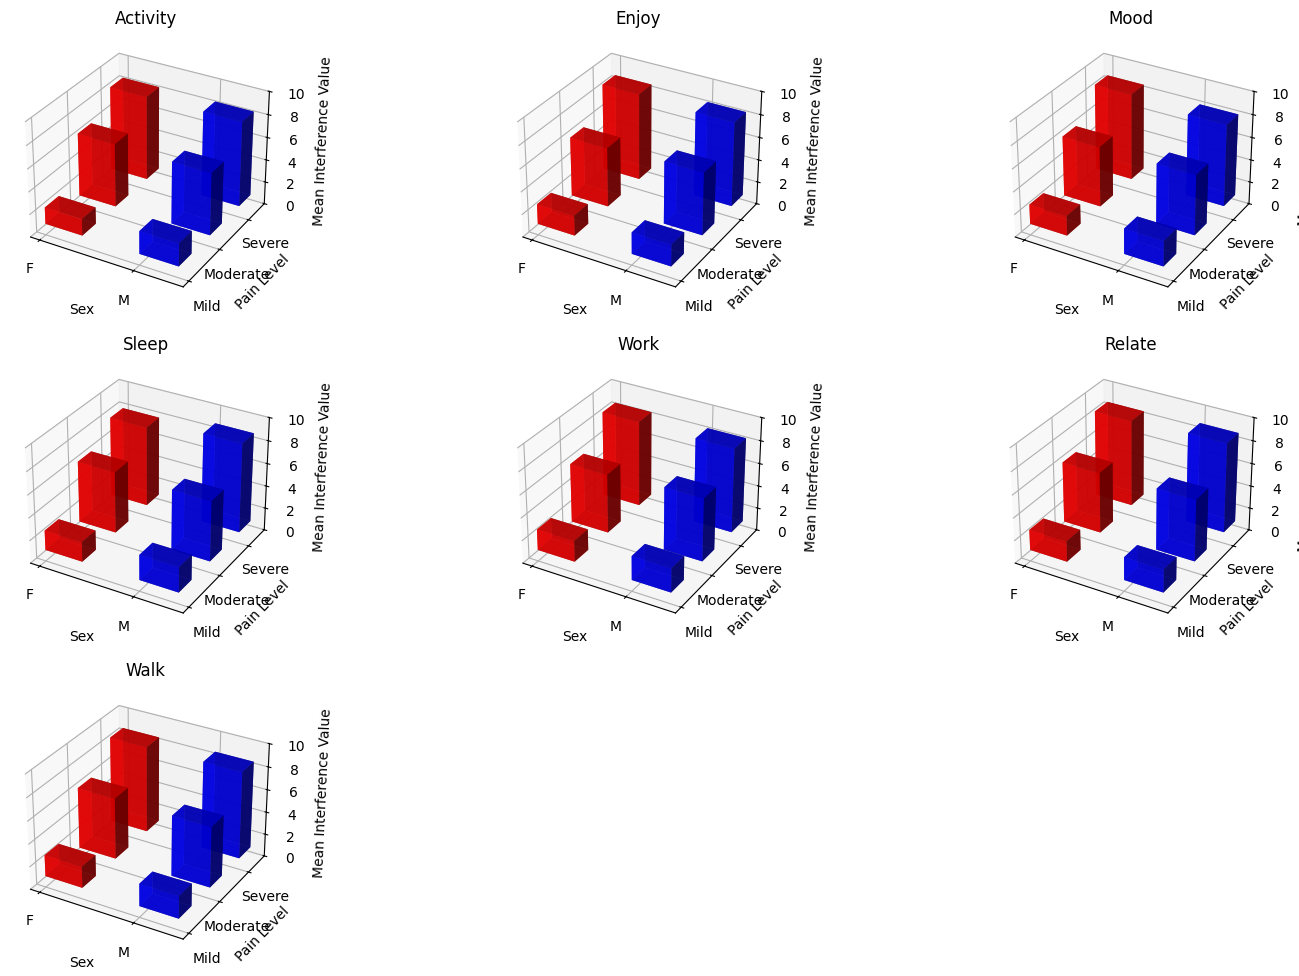

In [58]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  

def plot_3d_interference_by_sex(data, items, sex_col='Sex', pain_col='Pain_Level'):
    """
    Crea 7 subplot 3D (uno per ogni item in 'items') in cui:
      - Asse X = sesso (M, F)
      - Asse Y = livello di dolore (Mild, Moderate, Severe)
      - Asse Z = valore medio dell'item di interferenza (da 1 a 10).
    """
    pain_labels = ['Mild', 'Moderate','Severe' ]

    sexes = sorted(data[sex_col].dropna().unique())
    
#    print("Unique values in Sex column:", data[sex_col].unique())
#    print("Unique values in Pain_Level column:", data[pain_col].unique())    
    fig = plt.figure(figsize=(18, 12))
    
    for i, item in enumerate(items):
        ax = fig.add_subplot(3, 3, i + 1, projection='3d')
        
        group_means = data.groupby([sex_col, pain_col])[item].mean().reset_index()
#        print(group_means)
        
        dx = 0.4
        dy = 0.4
        base_value = 1 
        offset = 0.5  
        
        for s_i, sex_val in enumerate(sexes):
            for p_i, pain_level in enumerate(pain_labels):  
                
                
                subset = group_means[
                    (group_means[sex_col] == sex_val) & 
                    (group_means[pain_col] == pain_level)
                ]
                
                
                
                if len(subset) == 0:
                    mean_val = base_value  
                else:
                    mean_val = subset[item].values[0]
                
                x = s_i
                y = p_i
                color = 'blue' if sex_val == 'M' else 'red'
                
                dz = mean_val - base_value + offset
                
                if mean_val < base_value:
                    dz = offset  
                
                ax.bar3d(x, y, base_value, dx, dy, dz, color=color, alpha=0.8)
        
        ax.set_zlim(0, 10)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(sexes)
        ax.set_yticks(range(len(pain_labels)))
        ax.set_yticklabels(pain_labels)
        ax.set_xlabel('Sex')
        ax.set_ylabel('Pain Level')
        ax.set_zlabel('Mean Interference Value')
        ax.set_title(f'{item}')

    plt.tight_layout()
    plt.show()
    
items = ["Activity", "Enjoy", "Mood", "Sleep", "Work", "Relate", "Walk"]
plot_3d_interference_by_sex(df, items, sex_col='Sex', pain_col='Pain_Level')

Grafico salvato come: grouped_bar_1row_claude.pdf


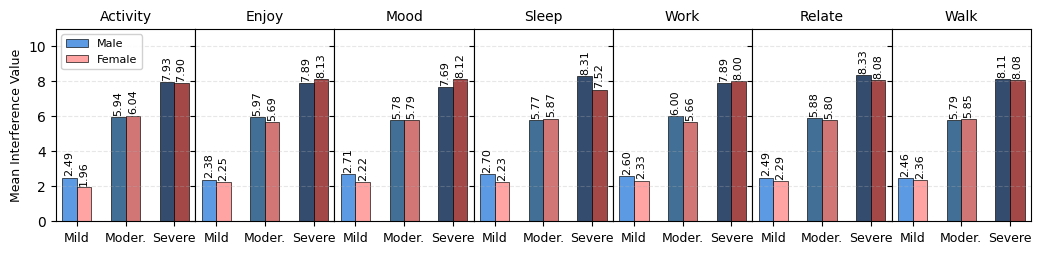

In [59]:
import matplotlib.pyplot as plt
import numpy as np

def plot_grouped_bar_interference_by_sex(data, items, sex_col='Sex', pain_col='Pain_Level', 
                                         save_path='grouped_bar_plot.pdf'):
    pain_labels = ['Mild', 'Moderate', 'Severe']
    
    colors = {
        'M': {
            'Mild': '#4A90E2',
            'Moderate': '#2C5F8A',
            'Severe': '#1E3A5F'
        },
        'F': {
            'Mild': '#FF9999',
            'Moderate': '#CC6666',
            'Severe': '#993333'
        }
    }
    
    fig, axes = plt.subplots(1, 7, figsize=(13, 2.5), sharey=True)
    plt.subplots_adjust(wspace=0,hspace=0, left=0.05, right=0.8)
    
    if len(items) == 1:
        axes = [axes]
    
    # Barre più compatte
    total_width = 0.6
    bar_width = total_width / 2
    offset = bar_width / 2
    
    positions = {
        'M': -offset,
        'F': +offset
    }
    
    for idx, (ax, item) in enumerate(zip(axes, items)):
        group_means = data.groupby([sex_col, pain_col])[item].mean().reset_index()
        
        x = np.arange(len(pain_labels))
        
        means = {}
        for sex in ['M', 'F']:
            for pain in pain_labels:
                val = group_means[(group_means[sex_col] == sex) & 
                                 (group_means[pain_col] == pain)][item].values
                means[f'{sex}_{pain}'] = val[0] if len(val) > 0 else 0
        
        for i, pain in enumerate(pain_labels):
            for sex in ['M', 'F']:
                val = means[f'{sex}_{pain}']
                if val > 0:
                    x_pos = x[i] + positions[sex]
                    
                    ax.bar(x_pos, val, bar_width,
                           color=colors[sex][pain],
                           edgecolor='black', linewidth=0.5,
                           alpha=0.9,
                           label=('Male' if sex == 'M' else 'Female') if i == 0 else "")
                    
                    # Testo centrato sulla barra
                    ax.text(x_pos, val + 0.1,
                            f'{val:.2f}',
                            ha='center', va='bottom', fontsize=8, rotation=90)
        
        ax.set_xticks(x)
        ax.set_xticklabels(['Mild', 'Moder.', 'Severe'], fontsize=9)
        ax.set_ylim(0, 11)
        
        # Y label solo nel primo subplot
        if idx == 0:
            ax.set_ylabel('Mean Interference Value', fontsize=9)
        else:
            ax.set_ylabel('')
        
        ax.set_title(f'{item}', fontsize=10)
        ax.grid(True, alpha=0.3, axis='y', linestyle='--')
        
        if idx == 0:
            ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
    
    #fig.suptitle('Interference by Sex and Pain Level', fontsize=14, y=1.02, fontweight='bold')
    
    # Subplot più vicini
    plt.subplots_adjust(wspace=0)
    
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
        print(f"Grafico salvato come: {save_path}")
    
    plt.show()



# UTILIZZO
items = ["Activity", "Enjoy", "Mood", "Sleep", "Work", "Relate", "Walk"]

plot_grouped_bar_interference_by_sex(df, items, sex_col='Sex', pain_col='Pain_Level', 
                                     save_path='grouped_bar_1row_claude.pdf')

In [100]:

dataset_path = f"C:/Users/carme/OneDrive/Desktop/Tesi Magistrale/Codice/dataset/McGill_Pain_Questionnaire_CLAUDE.csv"
df = pd.read_csv(dataset_path)
rename_columns = {
    'ID': 'ID',
    'Sex': 'Sex',
    'Age': 'Age',
    'BPM': 'BPM',
    'total_pain_score': 'Total_Pain_Score',
    'temporal': 'Temporal',
    'temporal_score': 'Temporal_Score',
    'spatial': 'Spatial',
    'spatial_score': 'Spatial_Score',
    'punctate': 'Punctate_Pressure',
    'Punctate_Pressure_Score': 'Punctate_Pressure_Score',  # se manca va rimossa
    'punctate_score': 'Punctate_Pressure_Score',
    'incisive': 'Incisive_Pressure',
    'incisive_score': 'Incisive_Pressure_Score',
    'constrictive': 'Constrictive_Pressure',
    'constrictive_score': 'Constrictive_Pressure_Score',
    'traction': 'Traction_Pressure',
    'Traction_Pressure_Score': 'Traction_Pressure_Score',
    'traction_score': 'Traction_Pressure_Score',
    'thermal': 'Thermal',
    'thermal_score': 'Thermal_Score',
    'brightness': 'Brightness',
    'brightness_score': 'Brightness_Score',
    'dullness': 'Dullness',
    'dullness_score': 'Dullness_Score',
    'sensory_misc': 'Sensory_Misc',
    'sensory_misc_score': 'Sensory_Misc_Score',
    'tension': 'Tension',
    'tension_score': 'Tension_Score',
    'autonomic': 'Autonomic',
    'autonomic_score': 'Autonomic_Score',
    'fear': 'Fear',
    'fear_score': 'Fear_Score',
    'punishment': 'Punishment',
    'punishment_score': 'Punishment_Score',
    'affective_evaluative_sensory': 'Affective_Eval_Sensory',
    'Affective_Eval_Sensory_Score': 'Affective_Eval_Sensory_Score',
    'affective_evaluative_sensory_score': 'Affective_Eval_Sensory_Score',
    'evaluative': 'Evaluative',
    'evaluative_score': 'Evaluative_Score',
    'sensory': 'Sensory',
    'sensory_score': 'Sensory_Score',
    'sensory_2': 'Sensory2',
    'sensory_2_score': 'Sensory2_Score',
    'sensory_3': 'Sensory3',
    'sensory_3_score': 'Sensory3_Score',
    'affective': 'Affective',
    'affective_score': 'Affective_Score',
    'pain_pattern': 'Pain_Pattern',
    'factor_liquor': 'liquor',
    'factor_stimulants_such_as_coffee': 'stimulants',
    'factor_eating': 'eating',
    'factor_heat': 'heat',
    'factor_cold': 'cold',
    'factor_damp': 'damp',
    'factor_weather_changes': 'weather_changes',
    'factor_massage_or_use_of_a_vibrator': 'massage',
    'factor_pressure': 'pressure',
    'factor_no_movement': 'no_movement',
    'factor_movement': 'movement',
    'factor_sleep_or_rest': 'sleep',
    'factor_lying_down': 'lying_down',
    'factor_distraction_TV_reading_etc': 'distraction',
    'factor_urination_or_defecation': 'urination',
    'factor_tension': 'tension',
    'factor_bright_lights': 'bright_lights',
    'factor_loud_noises': 'loud_noises',
    'factor_going_to_work': 'work',
    'factor_intercourse': 'intercourse',
    'factor_mild_exercise': 'mild_exercise',
    'factor_fatigue': 'fatigue',
    'pain_right_now': 'Pain_Now',
    'pain_right_now_score': 'Pain_Now_Score',
    'pain_at_worst': 'Pain_Worst',
    'pain_at_worst_score': 'Pain_Worst_Score',
    'pain_at_least': 'Pain_Least',
    'pain_at_least_score': 'Pain_Least_Score',
    'worst_toothache': 'Worst_Toothache',
    'worst_toothache_score': 'Worst_Toothache_Score',
    'worst_headache': 'Worst_Headache',
    'worst_headache_score': 'Worst_Headache_Score',
    'worst_stomachache': 'Worst_Stomachache',
    'worst_stomachache_score': 'Worst_Stomachache_Score',
    'interference_Activity': 'Activity',
    'interference_Enjoy': 'Enjoy',
    'interference_Mood': 'Mood',
    'interference_Relate': 'Relate',
    'interference_Sleep': 'Sleep',
    'interference_Walk': 'Walk',
    'interference_Work': 'Work',
    'pain_type': 'pain_type',
    'surgery_site': 'surgery_site',
    'tumor_sitology': 'tumor_sitology',
    'irradiation_site': 'irradiation_site',
    'osteoarthropathy': 'osteoarthropathy',
    'pain_projection': 'pain_projection'
}


df.rename(columns=rename_columns, inplace=True)
desired_scores = ['Temporal_Score', 'Spatial_Score', 
       'Punctate_Pressure_Score', 
       'Incisive_Pressure_Score', 
       'Constrictive_Pressure_Score', 
       'Traction_Pressure_Score',  'Thermal_Score', 
       'Brightness_Score',  'Dullness_Score', 
       'Sensory_Misc_Score', 'Tension_Score',
       'Autonomic_Score',  'Fear_Score', 
       'Punishment_Score', 
       'Affective_Eval_Sensory_Score', 'Evaluative_Score',
      'Sensory_Score',  'Sensory2_Score', 
       'Sensory3_Score',  'Affective_Score'
    
]
df['PRI'] = df[desired_scores].sum(axis=1)


var_factor=['liquor', 'stimulants', 'eating', 'heat', 'cold', 'damp',
       'weather_changes', 'massage', 'pressure', 'no_movement', 'movement',
       'sleep', 'lying_down', 'distraction', 'urination', 'tension',
       'bright_lights', 'loud_noises', 'work', 'intercourse', 'mild_exercise',
       'fatigue']
for col in df.columns:
    if col in var_factor:
        df[f'{col}'] = df[col].apply(lambda x: 1 if x == 'increase' else 0)
        
        desired_scores = ['Temporal_Score', 'Spatial_Score', 
       'Punctate_Pressure_Score', 
       'Incisive_Pressure_Score', 
       'Constrictive_Pressure_Score', 
       'Traction_Pressure_Score',  'Thermal_Score', 
       'Brightness_Score',  'Dullness_Score', 
       'Sensory_Misc_Score', 'Tension_Score',
       'Autonomic_Score',  'Fear_Score', 
       'Punishment_Score', 
       'Affective_Eval_Sensory_Score', 'Evaluative_Score',
      'Sensory_Score',  'Sensory2_Score', 
       'Sensory3_Score',  'Affective_Score', 'Pain_Now_Score', 
       'Pain_Worst_Score',  'Pain_Least_Score', 
       'Worst_Toothache_Score',  'Worst_Headache_Score',
       'Worst_Stomachache_Score', 'liquor', 'stimulants', 'eating', 'heat', 'cold', 'damp',
       'weather_changes', 'massage', 'pressure', 'no_movement', 'movement',
       'sleep', 'lying_down', 'distraction', 'urination', 'tension',
       'bright_lights', 'loud_noises', 'work', 'intercourse', 'mild_exercise',
       'fatigue'
    
]
df['Total Pain Score'] = df[desired_scores].sum(axis=1)
def discretizza_punteggio(punteggi, d):
    return [round((p / d) * 10) for p in punteggi]

df['scoring_3']=discretizza_punteggio(df['PRI'], 78)
df['scoring_4']=discretizza_punteggio(df['Total Pain Score'], 130)

variables = ["Activity", "Enjoy", "Mood", "Sleep", "Work", "Relate", "Walk"]

for var in variables:
     df[var] = 10 - df[var]

cut_off_models = {
    "CP37": [(1, 3), (4, 7), (8, 10)],
    "CP36": [(1, 3), (4, 6), (7, 10)],
    "CP47": [(1, 4), (5, 7), (8, 10)],
    "CP46": [(1, 4), (5, 6), (7, 10)]
}
def categorize_pain(pain_score, cutoffs):
    for idx, (low, high) in enumerate(cutoffs):
        if low <= pain_score <= high:
            return idx  # 0 = lieve, 1 = moderato, 2 = severo
    return np.nan
     
df["Pain_Level"] = df["scoring_3"].apply(lambda x: categorize_pain(x, cut_off_models["CP47"]))

In [102]:
cols_to_use = [col for col in df.columns if "score" not in col.lower()]
print(cols_to_use)
cols_to_use = [col for col in cols_to_use if col != "Pain_Level"]
results = {}

for col in cols_to_use:
    if np.issubdtype(df[col].dtype, np.number) and df[col].nunique() > 5:
        groups = [group[col].dropna() for name, group in df.groupby("Pain_Level")]
        try:
            f_val, p_val = stats.f_oneway(*groups)
            results[col] = {"type": "continuous", "ANOVA_F": f_val, "ANOVA_p": p_val}
        except Exception as e:
            results[col] = {"type": "continuous", "error": str(e)}
    else:
        contingency = pd.crosstab(df["Pain_Level"], df[col])
        try:
            chi2, p, dof, expected = stats.chi2_contingency(contingency)
            results[col] = {"type": "categorical", "chi2": chi2, "chi2_p": p, "dof": dof}
        except Exception as e:
            results[col] = {"type": "categorical", "error": str(e)}

for col, res in results.items():
    print(f"Variable: {col}")
    if res.get("type") == "continuous":
        if "error" in res:
            print(f"  ANOVA: Error - {res['error']}")
        else:
            print(f"  ANOVA: F = {res['ANOVA_F']:.3f}, p = {res['ANOVA_p']:.3f}")
    else:
        if "error" in res:
            print(f"  Chi-square: Error - {res['error']}")
        else:
            print(f"  Chi-square: chi2 = {res['chi2']:.3f}, p = {res['chi2_p']:.3f}, dof = {res['dof']}")
    print("--------------------------------------------------")

['ID', 'Sex', 'Age', 'BPM', 'Sensory', 'Fear', 'Sensory_Misc', 'Brightness', 'Affective', 'Thermal', 'Traction_Pressure', 'Tension', 'Evaluative', 'Dullness', 'Autonomic', 'Sensory3', 'Spatial', 'Affective_Eval_Sensory', 'Temporal', 'Punishment', 'Punctate_Pressure', 'Sensory2', 'Incisive_Pressure', 'Constrictive_Pressure', 'Pain_Pattern', 'liquor', 'stimulants', 'eating', 'heat', 'cold', 'damp', 'weather_changes', 'massage', 'pressure', 'no_movement', 'movement', 'sleep', 'lying_down', 'distraction', 'urination', 'tension', 'bright_lights', 'loud_noises', 'work', 'intercourse', 'mild_exercise', 'fatigue', 'Pain_Now', 'Pain_Worst', 'Pain_Least', 'Worst_Toothache', 'Worst_Headache', 'Worst_Stomachache', 'Activity', 'Enjoy', 'Mood', 'Relate', 'Sleep', 'Walk', 'Work', 'surgery_site', 'tumor_sitology', 'irradiation_site', 'osteoarthropathy', 'pain_projection', 'pain_type', 'PRI', 'scoring_3', 'scoring_4', 'Pain_Level']
Variable: ID
  ANOVA: F = 1.489, p = 0.227
----------------------------

In [103]:
import pandas as pd
import numpy as np
import scipy.stats as stats

def build_contingency_table(df, cat_vars, target='Pain_Level', p_threshold=0.11):
    """
    Costruisce una tabella riepilogativa con distribuzione e p-value (chi-quadro)
    per le variabili categoriali (o trattate come tali).
    
    Parametri:
    -----------
    df : pd.DataFrame
        Il DataFrame con i dati
    cat_vars : list of str
        Lista delle variabili categoriali da testare (senza "score")
    target : str
        Nome della variabile categoriale di riferimento (es. 'Pain_Level')
        con valori 0,1,2 (Mild, Moderate, Severe)
    p_threshold : float
        Soglia p-value per includere la variabile nella tabella finale.
        
    Ritorna:
    --------
    results_df : pd.DataFrame
        Tabella con righe corrispondenti alle categorie di ciascuna variabile
        e colonne con conteggi+percentuali per Pain_Level + p-value finale.
    """
    level_counts = df[target].value_counts(dropna=True)
    levels_order = [0, 1, 2]
    
    results_rows = []

    for var in cat_vars:
        ct = pd.crosstab(df[var], df[target])
        
        for lvl in levels_order:
            if lvl not in ct.columns:
                ct[lvl] = 0
        ct = ct[levels_order]
        
        chi2, p_val, dof, expected = stats.chi2_contingency(ct)
        
        if (p_val < p_threshold) or (var in ['Sex']):
            categories = ct.index.tolist()
            for i, cat in enumerate(categories):
                row_data = {}
                row_data['Variable'] = var if i == 0 else ""
                row_data['Category'] = str(cat)
                
                for lvl in levels_order:
                    count_val = ct.loc[cat, lvl]
                    total_lvl = level_counts.get(lvl, 0)
                    if total_lvl > 0:
                        perc = count_val * 100.0 / total_lvl
                    else:
                        perc = 0.0
                    row_data[f'Level_{lvl}'] = f"{count_val} ({perc:.1f}%)"
                
                if i == len(categories) - 1:
                    row_data['p-value'] = f"{p_val:.4f}"
                else:
                    row_data['p-value'] = ""
                
                results_rows.append(row_data)
    
    results_df = pd.DataFrame(results_rows)

    mild_n = level_counts.get(0, 0)
    mod_n = level_counts.get(1, 0)
    sev_n = level_counts.get(2, 0)

    results_df.rename(columns={
        'Level_0': f"Mild (n={mild_n})",
        'Level_1': f"Moderate (n={mod_n})",
        'Level_2': f"Severe (n={sev_n})"
    }, inplace=True)

    return results_df


all_cols = df.columns.tolist()

cat_vars = [c for c in all_cols if "score" not in c.lower()]

results_df = build_contingency_table(df, cat_vars, target='Pain_Level', p_threshold=0.11)
print(results_df)


                  Variable  Category  Mild (n=183) Moderate (n=114)  \
0                      Sex         F    96 (52.5%)       62 (54.4%)   
1                                  M    87 (47.5%)       52 (45.6%)   
2    Constrictive_Pressure  cramping    39 (21.3%)       22 (19.3%)   
3                           crushing    52 (28.4%)       14 (12.3%)   
4                            gnawing    30 (16.4%)       27 (23.7%)   
..                     ...       ...           ...              ...   
228                                8      0 (0.0%)         0 (0.0%)   
229                                9      0 (0.0%)         0 (0.0%)   
230             Pain_Level         0  183 (100.0%)         0 (0.0%)   
231                                1      0 (0.0%)     114 (100.0%)   
232                                2      0 (0.0%)         0 (0.0%)   

    Severe (n=203) p-value  
0      113 (55.7%)          
1       90 (44.3%)  0.8185  
2       39 (19.2%)          
3       38 (18.7%)          
4 

In [104]:
latex_code = results_df.to_latex(index=False)
print(latex_code)

\begin{tabular}{llllll}
\toprule
Variable & Category & Mild (n=183) & Moderate (n=114) & Severe (n=203) & p-value \\
\midrule
Sex & F & 96 (52.5%) & 62 (54.4%) & 113 (55.7%) &  \\
 & M & 87 (47.5%) & 52 (45.6%) & 90 (44.3%) & 0.8185 \\
Constrictive_Pressure & cramping & 39 (21.3%) & 22 (19.3%) & 39 (19.2%) &  \\
 & crushing & 52 (28.4%) & 14 (12.3%) & 38 (18.7%) &  \\
 & gnawing & 30 (16.4%) & 27 (23.7%) & 45 (22.2%) &  \\
 & pinching & 25 (13.7%) & 24 (21.1%) & 41 (20.2%) &  \\
 & pressing & 37 (20.2%) & 27 (23.7%) & 40 (19.7%) & 0.0460 \\
weather_changes & 0 & 122 (66.7%) & 72 (63.2%) & 154 (75.9%) &  \\
 & 1 & 61 (33.3%) & 42 (36.8%) & 49 (24.1%) & 0.0343 \\
massage & 0 & 111 (60.7%) & 72 (63.2%) & 146 (71.9%) &  \\
 & 1 & 72 (39.3%) & 42 (36.8%) & 57 (28.1%) & 0.0527 \\
loud_noises & 0 & 108 (59.0%) & 80 (70.2%) & 137 (67.5%) &  \\
 & 1 & 75 (41.0%) & 34 (29.8%) & 66 (32.5%) & 0.0919 \\
work & 0 & 116 (63.4%) & 68 (59.6%) & 144 (70.9%) &  \\
 & 1 & 67 (36.6%) & 46 (40.4%) & 59 (29.

In [106]:
df["Scoring_3"] = df["scoring_3"].apply(lambda x: categorize_pain(x, cut_off_models["CP47"]))

model_dir = "scoring_3 - model , claude"
os.makedirs(model_dir, exist_ok=True)

X = df[[ 'Temporal_Score', 'Spatial_Score', 'Punctate_Pressure_Score', 'Incisive_Pressure_Score', 'Constrictive_Pressure_Score', 'Traction_Pressure_Score', 'Thermal_Score', 'Brightness_Score', 'Dullness_Score', 'Sensory_Misc_Score', 'Tension_Score', 'Autonomic_Score', 'Fear_Score', 'Punishment_Score', 'Affective_Eval_Sensory_Score', 'Evaluative_Score', 'Sensory_Score', 'Sensory2_Score', 'Sensory3_Score', 'Affective_Score', 'Pain_Now_Score', 'Pain_Worst_Score', 'Pain_Least_Score', 'Worst_Toothache_Score', 'Worst_Headache_Score', 'Worst_Stomachache_Score', 'liquor',
 'stimulants',
 'eating',
 'heat',
 'cold',
 'damp',
 'weather_changes',
 'massage',
 'pressure',
 'no_movement',
 'movement',
 'sleep',
 'lying_down',
 'distraction',
 'urination',
 'tension',
 'bright_lights',
 'loud_noises',
 'work',
 'intercourse',
 'mild_exercise',
 'fatigue']]

y = df['Scoring_3'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "SVM": SVC(),
    "XGBoost": XGBClassifier( eval_metric='logloss'),
    "Bagging": BaggingClassifier(),
    "CART": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naïve Bayes": GaussianNB(),
    "Multinomial Logistic Regression": LogisticRegression(multi_class='multinomial', max_iter=200)
}

results = {}

for name, model in models.items():
    print(f"\nPerforming Stepwise Regression for {name}...")
    
    sfs = SequentialFeatureSelector(model, direction='backward', n_jobs=-1)
    sfs.fit(X_train, y_train)
    selected_features = X.columns[sfs.get_support()].tolist()
    
    print(f"Variabili selezionate per {name}: {selected_features}")
    
    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]
    
    model.fit(X_train, y_train)
    y_pred_all = model.predict(X_test)
    acc_all = accuracy_score(y_test, y_pred_all)
    report_all = classification_report(y_test, y_pred_all)
    matrix_all = confusion_matrix(y_test, y_pred_all)

    model.fit(X_train_selected, y_train)
    y_pred_selected = model.predict(X_test_selected)
    acc_selected = accuracy_score(y_test, y_pred_selected)
    report_selected = classification_report(y_test, y_pred_selected)
    matrix_selected = confusion_matrix(y_test, y_pred_selected)

    cross_val_score_all = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cross_val_score_selected = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='accuracy')
    
    results[name] = {
        "Accuracy (All features)": acc_all,
        "Classification Report (All features)": report_all,
        "Confusion Matrix (All features)": matrix_all,
        "Accuracy (Stepwise features)": acc_selected,
        "Classification Report (Stepwise features)": report_selected,
        "Confusion Matrix (Stepwise features)": matrix_selected,
        "Cross-validation Score (All features)": cross_val_score_all.mean(),
        "Cross-validation Score (Stepwise features)": cross_val_score_selected.mean()
    }

    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'wb') as file:
        pickle.dump(model, file)
    
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'wb') as file:
        pickle.dump(model, file)
    
    print(f"Modelli per {name} salvati in {model_filename_all} e {model_filename_selected}")
    print(f"Accuracy (All features): {acc_all}")
    print(f"Accuracy (Stepwise features): {acc_selected}")
    print("Classification Report (All features):\n", report_all)
    print("Classification Report (Stepwise features):\n", report_selected)

loaded_models = {}
for name in models.keys():
    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'rb') as file:
        loaded_models[name + "_all_features"] = pickle.load(file)
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'rb') as file:
        loaded_models[name + "_selected_features"] = pickle.load(file)
    print(f"Modelli {name} caricati correttamente da {model_filename_all} e {model_filename_selected}")



Performing Stepwise Regression for SVM...
Variabili selezionate per SVM: ['Temporal_Score', 'Spatial_Score', 'Punctate_Pressure_Score', 'Incisive_Pressure_Score', 'Traction_Pressure_Score', 'Thermal_Score', 'Brightness_Score', 'Dullness_Score', 'Sensory_Misc_Score', 'Tension_Score', 'Autonomic_Score', 'Fear_Score', 'Punishment_Score', 'Affective_Eval_Sensory_Score', 'Evaluative_Score', 'Sensory_Score', 'Sensory2_Score', 'Sensory3_Score', 'Affective_Score', 'Worst_Headache_Score', 'weather_changes', 'massage', 'urination', 'loud_noises']
Modelli per SVM salvati in scoring_3 - model , claude\SVM_all_features.pkl e scoring_3 - model , claude\SVM_selected_features.pkl
Accuracy (All features): 0.98
Accuracy (Stepwise features): 0.94
Classification Report (All features):
               precision    recall  f1-score   support

           0       0.97      1.00      0.99        34
           1       1.00      0.92      0.96        24
           2       0.98      1.00      0.99        42

    

c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:465: Conver

Modelli per Multinomial Logistic Regression salvati in scoring_3 - model , claude\Multinomial Logistic Regression_all_features.pkl e scoring_3 - model , claude\Multinomial Logistic Regression_selected_features.pkl
Accuracy (All features): 0.94
Accuracy (Stepwise features): 0.93
Classification Report (All features):
               precision    recall  f1-score   support

           0       0.94      1.00      0.97        34
           1       1.00      0.75      0.86        24
           2       0.91      1.00      0.95        42

    accuracy                           0.94       100
   macro avg       0.95      0.92      0.93       100
weighted avg       0.94      0.94      0.94       100

Classification Report (Stepwise features):
               precision    recall  f1-score   support

           0       0.92      0.97      0.94        34
           1       0.90      0.79      0.84        24
           2       0.95      0.98      0.96        42

    accuracy                           

# Scoring 4, word-based

In [64]:
descriptor_columns = ['Temporal',
        'Spatial', 'Punctate_Pressure',
       'Incisive_Pressure',
        'Constrictive_Pressure', 'Traction_Pressure', 'Thermal',  'Brightness',
      'Dullness',  'Sensory_Misc','Tension',  'Autonomic',
        'Fear',  'Punishment',
        'Affective_Eval_Sensory','Evaluative', 
       'Sensory',  'Sensory2',  'Sensory3',
        'Affective']

df_long = pd.melt(df, 
                  id_vars=["ID", "pain_type"], 
                  value_vars=descriptor_columns, 
                  var_name="Descriptor_Type", 
                  value_name="Descriptor")

df_long = df_long.dropna(subset=["Descriptor"])

freq_table = df_long.groupby(["Descriptor", "pain_type"]).size().unstack(fill_value=0)
freq_table["Totale"] = freq_table.sum(axis=1)
freq_table = freq_table.sort_values(by="Totale", ascending=False)
print(freq_table.head(20))


pain_type    neuropathic  nociceptive  Totale
Descriptor                                   
wretched             192           67     259
tiring               183           70     253
sickening            193           58     251
suffocating          179           70     249
exhausting           189           58     247
blinding             180           61     241
boring               165           57     222
frightful            150           46     196
shooting             149           44     193
sharp                148           36     184
lacerating           123           54     177
cool                 116           59     175
wrenching            131           40     171
pulling              129           38     167
freezing             128           37     165
tugging              112           50     162
jumping              115           46     161
cold                 128           32     160
fearful              118           37     155
terrifying           104          

In [65]:
freq_table

pain_type,neuropathic,nociceptive,Totale
Descriptor,,,
wretched,192,67,259
tiring,183,70,253
sickening,193,58,251
suffocating,179,70,249
exhausting,189,58,247
...,...,...,...
sore,63,24,87
pulsing,58,26,84
lancinating,64,20,84


In [66]:
import pandas as pd
import numpy as np
from collections import Counter

descriptor_columns = ['Temporal',
        'Spatial', 'Punctate_Pressure',
       'Incisive_Pressure',
        'Constrictive_Pressure', 'Traction_Pressure', 'Thermal',  'Brightness',
      'Dullness',  'Sensory_Misc','Tension',  'Autonomic',
        'Fear',  'Punishment',
        'Affective_Eval_Sensory','Evaluative', 
       'Sensory',  'Sensory2',  'Sensory3',
        'Affective']

df_long = pd.melt(df, 
                  id_vars=["ID", "pain_type"], 
                  value_vars=descriptor_columns, 
                  var_name="Descriptor_Type", 
                  value_name="Descriptor")
df_long = df_long.dropna(subset=["Descriptor"])
df_long["Descriptor"] = df_long["Descriptor"].str.strip().str.lower()


df_sites = df_long.groupby(["ID", "pain_type"])["Descriptor"].apply(lambda x: list(set(x))).reset_index()
all_descriptors = set([desc for sublist in df_sites["Descriptor"] for desc in sublist])
print("Numero di descrittori unici:", len(all_descriptors))

for desc in all_descriptors:
    df_sites[desc] = df_sites["Descriptor"].apply(lambda lst: 1 if desc in lst else 0)

print(df_sites.head())

# Analisi univariata: per ogni descrittore, costruiamo la tabella di contingenza (presenza/assenza x pain_type)
results = []  
for desc in sorted(all_descriptors):
    # tabella 2x2: righe = [descrittore presente, non presente], colonne = pain_type
    table = pd.crosstab(df_sites[desc], df_sites["pain_type"])
    if 0 not in table.index:
        table.loc[0] = 0
    if 1 not in table.index:
        table.loc[1] = 0
    if "nociceptive" not in table.columns:
        table["nociceptive"] = 0
    if "neuropathic" not in table.columns:
        table["neuropathic"] = 0
    table = table.sort_index()
    try:
        oddsratio, p_value = stats.fisher_exact(table)
    except Exception as e:
        oddsratio, p_value = np.nan, np.nan
    results.append({
        "Descriptor": desc,
        "OddsRatio": oddsratio,
        "p_value": p_value,
        "Contingency": table.values.tolist()
    })

df_results = pd.DataFrame(results)
df_results = df_results.sort_values("p_value")
print("Risultati test univariati (prime righe):")
pd.set_option("display.max_rows", None)  # Mostra tutte le righe
print(df_results)
significant_descriptors = df_results[df_results["p_value"] < 0.05]["Descriptor"].tolist()
print("Descrittori significativi (p < 0.05):", significant_descriptors)




Numero di descrittori unici: 77
   ID    pain_type                                         Descriptor  \
0   1  nociceptive  [hot, exhausting, unbearable, pinching, suffoc...   
1   2  nociceptive  [stabbing, exhausting, pressing, sickening, ra...   
2   3  neuropathic  [hot, exhausting, pulsing, sickening, pulling,...   
3   4  nociceptive  [tugging, exhausting, pressing, sickening, fre...   
4   5  neuropathic  [dreadful, pulsing, suffocating, wrenching, ti...   

   stabbing  annoying  pulsing  pressing  unbearable  gnawing  tiring  ...  \
0         0         0        0         0           1        0       0  ...   
1         1         0        0         1           0        0       0  ...   
2         0         0        1         0           0        0       0  ...   
3         0         0        0         1           0        0       0  ...   
4         0         0        1         0           0        0       1  ...   

   flickering  tight  intense  taut  killing  penetrating  p

In [ ]:
tot_noc = df_sites[df_sites["pain_type"] == "nociceptive"].shape[0]
tot_neu = df_sites[df_sites["pain_type"] == "neuropathic"].shape[0]

latex_rows = []
for _, row in df_results.iterrows():
    desc = row["Descriptor"]
    p = row["p_value"]
    orr = row["OddsRatio"]

    # Frequenze
    count_noc = df_sites[df_sites["pain_type"] == "nociceptive"][desc].sum()
    count_neu = df_sites[df_sites["pain_type"] == "neuropathic"][desc].sum()
    perc_noc = 100 * count_noc / tot_noc
    perc_neu = 100 * count_neu / tot_neu

    # P-value formattato
    if pd.isna(p):
        p_str = "n.a."
    elif p < 0.001:
        p_str = "\\textbf{< 0.001***}"
    elif p < 0.01:
        p_str = "\\textbf{" + f"{p:.3f}" + "**}"
    elif p < 0.05:
        p_str = "\\textbf{" + f"{p:.3f}" + "*}"
    else:
        p_str = f"{p:.3f}"

    # Odds ratio
    orr_str = f"{orr:.2f}" if not pd.isna(orr) else "n.a."

    row_str = f"\\quad {desc} & {int(count_noc)} ({perc_noc:.1f}\\%) & {int(count_neu)} ({perc_neu:.1f}\\%) & {orr_str} & {p_str} \\\\"
    latex_rows.append(row_str)

# Stampa la tabella
print("\n".join(latex_rows))


\quad piercing & 70 (54.7\%) & 63 (16.9\%) & 5.92 & \textbf{< 0.001***} \\
\quad radiating & 2 (1.6\%) & 116 (31.2\%) & 0.04 & \textbf{< 0.001***} \\
\quad spreading & 8 (6.2\%) & 113 (30.4\%) & 0.15 & \textbf{< 0.001***} \\
\quad aching & 42 (32.8\%) & 61 (16.4\%) & 2.49 & \textbf{< 0.001***} \\
\quad hurting & 11 (8.6\%) & 84 (22.6\%) & 0.32 & \textbf{< 0.001***} \\
\quad penetrating & 48 (37.5\%) & 80 (21.5\%) & 2.19 & \textbf{< 0.001***} \\
\quad cool & 59 (46.1\%) & 116 (31.2\%) & 1.89 & \textbf{0.003**} \\
\quad quivering & 10 (7.8\%) & 68 (18.3\%) & 0.38 & \textbf{0.004**} \\
\quad stabbing & 17 (13.3\%) & 86 (23.1\%) & 0.51 & \textbf{0.016*} \\
\quad sharp & 36 (28.1\%) & 148 (39.8\%) & 0.59 & \textbf{0.019*} \\
\quad stinging & 46 (35.9\%) & 93 (25.0\%) & 1.68 & \textbf{0.022*} \\
\quad tingling & 21 (16.4\%) & 96 (25.8\%) & 0.56 & \textbf{0.030*} \\
\quad killing & 32 (25.0\%) & 63 (16.9\%) & 1.63 & 0.050 \\
\quad throbbing & 30 (23.4\%) & 58 (15.6\%) & 1.66 & 0.059 \\
\quad 

In [110]:
df['pain_type'].value_counts()

pain_type
neuropathic    372
nociceptive    128
Name: count, dtype: int64

In [114]:
import pandas as pd
import numpy as np
import scipy.stats as stats

def calculate_metrics(df, descriptor, target_type):
    """
    Calcola TP, FN, FP, TN, sensitivity, specificity e PPV per il descrittore specificato.
    
    Parameters:
      df: DataFrame che contiene la colonna binaria per il descrittore e "pain_type".
      descriptor: stringa, nome del descrittore (in minuscolo, corrispondente a una colonna numerica 0/1).
      target_type: stringa, "nociceptive" oppure "neuropathic" (il gruppo in cui il descrittore è maggiormente selezionato).
      
    Returns:
      Un dizionario con le metriche e la tabella di contingenza.
    """
    table = pd.crosstab(df[descriptor], df["pain_type"])
    
    if 0 not in table.index:
        table.loc[0] = 0
    if 1 not in table.index:
        table.loc[1] = 0
    table = table.sort_index()
    
    if target_type == "nociceptive":
        TP = table.loc[1, "nociceptive"]   # descrittore presente in siti nociceptive
        FN = table.loc[0, "nociceptive"]   # descrittore assente in siti nociceptive
        FP = table.loc[1, "neuropathic"]     # descrittore presente in siti neuropathic
        TN = table.loc[0, "neuropathic"]     # descrittore assente in siti neuropathic
    elif target_type == "neuropathic":
        TP = table.loc[1, "neuropathic"]     # descrittore presente in siti neuropathic
        FN = table.loc[0, "neuropathic"]     # descrittore assente in siti neuropathic
        FP = table.loc[1, "nociceptive"]     # descrittore presente in siti nociceptive
        TN = table.loc[0, "nociceptive"]     # descrittore assente in siti nociceptive
    else:
        raise ValueError("target_type deve essere 'nociceptive' o 'neuropathic'")
    
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan
    PPV = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    
    return {
        "TP": TP,
        "FN": FN,
        "FP": FP,
        "TN": TN,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "PPV": PPV,
        "Contingency": table
    }


 
neurop_descriptors = ["radiating", "spreading", "hurting", "quivering", "stabbing", "sharp", "tingling"]
noc_descriptors = ["piercing", "aching", "penetrating", "cool", "stinging", "killing"]
df_sites["pain_type"] = df_sites["pain_type"].str.lower()

results_metrics = {}

print("Metrica per descrittori associati a dolore nociceptive:")
for word in noc_descriptors:
    descriptor_col = word  
    metrics = calculate_metrics(df_sites, descriptor_col, target_type="nociceptive")
    results_metrics[word] = metrics
    print(f"{word}:")
    print(f"  TP={metrics['TP']}, FN={metrics['FN']}, FP={metrics['FP']}, TN={metrics['TN']}")
    print(f"  Sensitivity = {metrics['sensitivity']:.2f}")
    print(f"  Specificity = {metrics['specificity']:.2f}")
    print(f"  PPV = {metrics['PPV']:.2f}")
    print("  Contingency Table:")
    print(metrics["Contingency"])
    print("")

print("Metrica per descrittori associati a dolore neuropathic:")
for word in neurop_descriptors:
    descriptor_col = word  
    metrics = calculate_metrics(df_sites, descriptor_col, target_type="neuropathic")
    results_metrics[word] = metrics
    print(f"{word}:")
    print(f"  TP={metrics['TP']}, FN={metrics['FN']}, FP={metrics['FP']}, TN={metrics['TN']}")
    print(f"  Sensitivity = {metrics['sensitivity']:.2f}")
    print(f"  Specificity = {metrics['specificity']:.2f}")
    print(f"  PPV = {metrics['PPV']:.2f}")
    print("  Contingency Table:")
    print(metrics["Contingency"])
    print("")


Metrica per descrittori associati a dolore nociceptive:
piercing:
  TP=70, FN=58, FP=63, TN=309
  Sensitivity = 0.55
  Specificity = 0.83
  PPV = 0.53
  Contingency Table:
pain_type  neuropathic  nociceptive
piercing                           
0                  309           58
1                   63           70

aching:
  TP=42, FN=86, FP=61, TN=311
  Sensitivity = 0.33
  Specificity = 0.84
  PPV = 0.41
  Contingency Table:
pain_type  neuropathic  nociceptive
aching                             
0                  311           86
1                   61           42

penetrating:
  TP=48, FN=80, FP=80, TN=292
  Sensitivity = 0.38
  Specificity = 0.78
  PPV = 0.38
  Contingency Table:
pain_type    neuropathic  nociceptive
penetrating                          
0                    292           80
1                     80           48

cool:
  TP=59, FN=69, FP=116, TN=256
  Sensitivity = 0.46
  Specificity = 0.69
  PPV = 0.34
  Contingency Table:
pain_type  neuropathic  nociceptive
coo

In [116]:
def format_percent(value):
    return f"{int(round(value * 100))}\%" if pd.notnull(value) else "NA"

neurop_descriptors = ["radiating", "spreading", "hurting", "quivering", "stabbing", "sharp", "tingling"]
noc_descriptors = ["piercing", "aching", "penetrating", "cool", "stinging", "killing"]
df_sites["pain_type"] = df_sites["pain_type"].str.lower()
latex_table = r"""\begin{table}[h!]
\centering
\renewcommand{\arraystretch}{1.3}
\label{tab:ability_to_predict}
\caption{Sensitivity, Specificity e Positive Predictive Value per ogni parola statisticamente significativa che discrimina pain site nocicettivo e neuropatico}
\resizebox{\textwidth}{!}{
\begin{tabular}{lccc}
\toprule
& \multicolumn{3}{c}{\textbf{Ability to Predict Neuropathic Pain}} \\
\cline{2-4}
\textbf{Neuropathic Words} & \textbf{Sensitivity} & \textbf{Specificity} & \textbf{Positive Predictive Value} \\
\cline{2-4}
"""

# Neuropathic words
for word in neurop_descriptors:
    metrics = calculate_metrics(df_sites, word, target_type="neuropathic")
    sensitivity = format_percent(metrics['sensitivity'])
    specificity = format_percent(metrics['specificity'])
    ppv = format_percent(metrics['PPV'])
    latex_table += f"{word.capitalize()} & {sensitivity} & {specificity} & {ppv} \\\\\n"

latex_table += r"""\hline
& \multicolumn{3}{c}{\textbf{Ability to Predict Nociceptive Pain}} \\
\cline{2-4}
\textbf{Nociceptive Words} & \textbf{Sensitivity} & \textbf{Specificity} & \textbf{Positive Predictive Value} \\
\cline{2-4}
"""

# Nociceptive words
for word in noc_descriptors:
    metrics = calculate_metrics(df_sites, word, target_type="nociceptive")
    sensitivity = format_percent(metrics['sensitivity'])
    specificity = format_percent(metrics['specificity'])
    ppv = format_percent(metrics['PPV'])
    latex_table += f"{word.capitalize()} & {sensitivity} & {specificity} & {ppv} \\\\\n"

latex_table += r"""\hline
\end{tabular}}
\end{table}
"""

print(latex_table)


\begin{table}[h!]
\centering
\renewcommand{\arraystretch}{1.3}
\label{tab:ability_to_predict}
\caption{Sensitivity, Specificity e Positive Predictive Value per ogni parola statisticamente significativa che discrimina pain site nocicettivo e neuropatico}
\resizebox{\textwidth}{!}{
\begin{tabular}{lccc}
\toprule
& \multicolumn{3}{c}{\textbf{Ability to Predict Neuropathic Pain}} \\
\cline{2-4}
\textbf{Neuropathic Words} & \textbf{Sensitivity} & \textbf{Specificity} & \textbf{Positive Predictive Value} \\
\cline{2-4}
Radiating & 31\% & 98\% & 98\% \\
Spreading & 30\% & 94\% & 93\% \\
Hurting & 23\% & 91\% & 88\% \\
Quivering & 18\% & 92\% & 87\% \\
Stabbing & 23\% & 87\% & 83\% \\
Sharp & 40\% & 72\% & 80\% \\
Tingling & 26\% & 84\% & 82\% \\
\hline
& \multicolumn{3}{c}{\textbf{Ability to Predict Nociceptive Pain}} \\
\cline{2-4}
\textbf{Nociceptive Words} & \textbf{Sensitivity} & \textbf{Specificity} & \textbf{Positive Predictive Value} \\
\cline{2-4}
Piercing & 55\% & 83\% & 53\% \\
Achi

In [ ]:
from sklearn.metrics import classification_report
import re
model_dir = "scoring_4 - model , claude"
os.makedirs(model_dir, exist_ok=True)


df_sites["pain_binary"] = df_sites["pain_type"].apply(lambda x: 1 if x.lower() == "neuropathic" else 0)
selected_descriptors = ["radiating", "spreading", "hurting", "quivering", "stabbing", "sharp", "tingling", "piercing", "aching", "penetrating", "cool", "stinging", "killing"]

X = df_sites[selected_descriptors]
y = df_sites["pain_binary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "SVM": SVC(),
    "XGBoost": XGBClassifier( eval_metric='logloss'),
    "Bagging": BaggingClassifier(),
    "CART": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naïve Bayes": GaussianNB(),
    "Multinomial Logistic Regression": LogisticRegression(multi_class='multinomial', max_iter=200)
}

results = {}

for name, model in models.items():
    print(f"\nPerforming Stepwise Regression for {name}...")
    
    sfs = SequentialFeatureSelector(model, direction='backward', n_jobs=-1)
    sfs.fit(X_train, y_train)
    selected_features = X.columns[sfs.get_support()].tolist()
    
    print(f"Variabili selezionate per {name}: {selected_features}")
    
    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]
    
    model.fit(X_train, y_train)
    y_pred_all = model.predict(X_test)
    acc_all = accuracy_score(y_test, y_pred_all)
    report_all = classification_report(y_test, y_pred_all)
    matrix_all = confusion_matrix(y_test, y_pred_all)

    model.fit(X_train_selected, y_train)
    y_pred_selected = model.predict(X_test_selected)
    acc_selected = accuracy_score(y_test, y_pred_selected)
    report_selected = classification_report(y_test, y_pred_selected)
    matrix_selected = confusion_matrix(y_test, y_pred_selected)

    cross_val_score_all = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cross_val_score_selected = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='accuracy')
    
    results[name] = {
        "Accuracy (All features)": acc_all,
        "Classification Report (All features)": report_all,
        "Confusion Matrix (All features)": matrix_all,
        "Accuracy (Stepwise features)": acc_selected,
        "Classification Report (Stepwise features)": report_selected,
        "Confusion Matrix (Stepwise features)": matrix_selected,
        "Cross-validation Score (All features)": cross_val_score_all.mean(),
        "Cross-validation Score (Stepwise features)": cross_val_score_selected.mean()
    }

    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'wb') as file:
        pickle.dump(model, file)
    
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'wb') as file:
        pickle.dump(model, file)
    
    print(f"Modelli per {name} salvati in {model_filename_all} e {model_filename_selected}")
    print(f"Accuracy (All features): {acc_all}")
    print(f"Accuracy (Stepwise features): {acc_selected}")
    print("Classification Report (All features):\n", report_all)
    print("Classification Report (Stepwise features):\n", report_selected)

loaded_models = {}
for name in models.keys():
    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'rb') as file:
        loaded_models[name + "_all_features"] = pickle.load(file)
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'rb') as file:
        loaded_models[name + "_selected_features"] = pickle.load(file)
    print(f"Modelli {name} caricati correttamente da {model_filename_all} e {model_filename_selected}")
    
    
from sklearn.metrics import classification_report
import re

def parse_report(report_text):
    """
    Estrae precision, recall, f1-score per ciascuna classe e macro avg da classification_report.
    Restituisce un dizionario.
    """
    lines = report_text.strip().split("\n")
    results = {}
    
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 4:
            continue

        # Per linee tipo "0", "1", "macro avg", etc.
        label = " ".join(parts[:-4]) if not parts[0].replace('.', '').isdigit() else parts[0]
        try:
            precision = float(parts[-4])
            recall = float(parts[-3])
            f1_score = float(parts[-2])
            results[label.strip()] = {
                "precision": precision,
                "recall": recall,
                "f1-score": f1_score
            }
        except ValueError:
            continue  # Salta righe che non contengono numeri validi

    return results


def format_float(x):
    return f"{x:.2f}" if isinstance(x, float) else "NA"

latex_rows = []
def safe_get(parsed, label, metric):
    try:
        return f"{parsed[label][metric]:.2f}"
    except:
        return "NA"

latex_rows = []
for model_name, metrics in results.items():
    for feat_type in ["All features", "Stepwise features"]:
        report_text = metrics[f"Classification Report ({feat_type})"]
        parsed = parse_report(report_text)

        prec_0 = safe_get(parsed, "0", "precision")
        rec_0 = safe_get(parsed, "0", "recall")
        f1_0 = safe_get(parsed, "0", "f1-score")

        prec_1 = safe_get(parsed, "1", "precision")
        rec_1 = safe_get(parsed, "1", "recall")
        f1_1 = safe_get(parsed, "1", "f1-score")

        # Classe 2: potrebbe non esistere
        prec_2 = safe_get(parsed, "2", "precision")
        rec_2 = safe_get(parsed, "2", "recall")
        f1_2 = safe_get(parsed, "2", "f1-score")

        # Macro Avg: aggregato delle medie
        prec_macro = safe_get(parsed, "macro avg", "precision")
        rec_macro = safe_get(parsed, "macro avg", "recall")
        f1_macro = safe_get(parsed, "macro avg", "f1-score")

        acc = f"{metrics[f'Accuracy ({feat_type})']:.2f}"

        latex_rows.append(
            f"{model_name} & {('STPWS' if feat_type == 'Stepwise features' else 'All features')} & "
            f"{prec_0} & {rec_0} & {f1_0} & "
            f"{prec_1} & {rec_1} & {f1_1} & "
            f"{prec_2} & {rec_2} & {f1_2} & "
            f"{prec_macro} & {rec_macro} & {f1_macro} & {acc} \\\\"
        )


print("\\begin{table}[H]")
print("    \\centering")
print("    \\caption{Metriche di classificazione per ogni modello e classe, scoring 4}")
print("    \\label{tab:scoring_4_model_gpt}")
print("    \\resizebox{\\textwidth}{!}{")
print("    \\begin{tabular}{l p{2cm} ccc|ccc|ccc|ccc|c}")
print("        \\toprule")
print("        \\textbf{Modello} & \\textbf{Variabili} & \\multicolumn{3}{c|}{\\textbf{Classe 0}} & "
      "\\multicolumn{3}{c|}{\\textbf{Classe 1}} & \\multicolumn{3}{c|}{\\textbf{Classe 2}} & "
      "\\multicolumn{3}{c|}{\\textbf{Macro Avg}} & \\textbf{Acc.} \\\\")
print("        \\cmidrule(lr){3-5} \\cmidrule(lr){6-8} \\cmidrule(lr){9-11} \\cmidrule(lr){12-14}")
print("        & & Prec. & Recall & F1 & Prec. & Recall & F1 & Prec. & Recall & F1 & Prec. & Recall & F1 & \\\\")
print("        \\midrule")
for row in latex_rows:
    print("        " + row)
print("        \\bottomrule")
print("    \\end{tabular}")
print("    }")
print("\\end{table}")

3


Performing Stepwise Regression for SVM...
Variabili selezionate per SVM: ['spreading', 'tingling', 'piercing', 'aching', 'penetrating', 'cool', 'stinging']
Modelli per SVM salvati in scoring_4 - model , claude\SVM_all_features.pkl e scoring_4 - model , claude\SVM_selected_features.pkl
Accuracy (All features): 0.74
Accuracy (Stepwise features): 0.75
Classification Report (All features):
               precision    recall  f1-score   support

           0       0.50      0.35      0.41        26
           1       0.79      0.88      0.83        74

    accuracy                           0.74       100
   macro avg       0.65      0.61      0.62       100
weighted avg       0.72      0.74      0.72       100

Classification Report (Stepwise features):
               precision    recall  f1-score   support

           0       0.55      0.23      0.32        26
           1       0.78      0.93      0.85        74

    accuracy                           0.75       100
   macro avg       0

c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic

Modelli SVM caricati correttamente da scoring_4 - model , claude\SVM_all_features.pkl e scoring_4 - model , claude\SVM_selected_features.pkl
Modelli XGBoost caricati correttamente da scoring_4 - model , claude\XGBoost_all_features.pkl e scoring_4 - model , claude\XGBoost_selected_features.pkl
Modelli Bagging caricati correttamente da scoring_4 - model , claude\Bagging_all_features.pkl e scoring_4 - model , claude\Bagging_selected_features.pkl
Modelli CART caricati correttamente da scoring_4 - model , claude\CART_all_features.pkl e scoring_4 - model , claude\CART_selected_features.pkl
Modelli Random Forest caricati correttamente da scoring_4 - model , claude\Random Forest_all_features.pkl e scoring_4 - model , claude\Random Forest_selected_features.pkl
Modelli Naïve Bayes caricati correttamente da scoring_4 - model , claude\Naïve Bayes_all_features.pkl e scoring_4 - model , claude\Naïve Bayes_selected_features.pkl
Modelli Multinomial Logistic Regression caricati correttamente da scoring

3

# Scoring 5, dolore acuto o cronico

In [22]:

dataset_path = f"C:/Users/carme/OneDrive/Desktop/Tesi Magistrale/Codice/dataset/McGill_Pain_Questionnaire_CLAUDE.csv"
df = pd.read_csv(dataset_path)
rename_columns = {
    'ID': 'ID',
    'Sex': 'Sex',
    'Age': 'Age',
    'BPM': 'BPM',
    'total_pain_score': 'Total_Pain_Score',
    'temporal': 'Temporal',
    'temporal_score': 'Temporal_Score',
    'spatial': 'Spatial',
    'spatial_score': 'Spatial_Score',
    'punctate': 'Punctate_Pressure',
    'Punctate_Pressure_Score': 'Punctate_Pressure_Score',  # se manca va rimossa
    'punctate_score': 'Punctate_Pressure_Score',
    'incisive': 'Incisive_Pressure',
    'incisive_score': 'Incisive_Pressure_Score',
    'constrictive': 'Constrictive_Pressure',
    'constrictive_score': 'Constrictive_Pressure_Score',
    'traction': 'Traction_Pressure',
    'Traction_Pressure_Score': 'Traction_Pressure_Score',
    'traction_score': 'Traction_Pressure_Score',
    'thermal': 'Thermal',
    'thermal_score': 'Thermal_Score',
    'brightness': 'Brightness',
    'brightness_score': 'Brightness_Score',
    'dullness': 'Dullness',
    'dullness_score': 'Dullness_Score',
    'sensory_misc': 'Sensory_Misc',
    'sensory_misc_score': 'Sensory_Misc_Score',
    'tension': 'Tension',
    'tension_score': 'Tension_Score',
    'autonomic': 'Autonomic',
    'autonomic_score': 'Autonomic_Score',
    'fear': 'Fear',
    'fear_score': 'Fear_Score',
    'punishment': 'Punishment',
    'punishment_score': 'Punishment_Score',
    'affective_evaluative_sensory': 'Affective_Eval_Sensory',
    'Affective_Eval_Sensory_Score': 'Affective_Eval_Sensory_Score',
    'affective_evaluative_sensory_score': 'Affective_Eval_Sensory_Score',
    'evaluative': 'Evaluative',
    'evaluative_score': 'Evaluative_Score',
    'sensory': 'Sensory',
    'sensory_score': 'Sensory_Score',
    'sensory_2': 'Sensory2',
    'sensory_2_score': 'Sensory2_Score',
    'sensory_3': 'Sensory3',
    'sensory_3_score': 'Sensory3_Score',
    'affective': 'Affective',
    'affective_score': 'Affective_Score',
    'pain_pattern': 'Pain_Pattern',
    'factor_liquor': 'liquor',
    'factor_stimulants_such_as_coffee': 'stimulants',
    'factor_eating': 'eating',
    'factor_heat': 'heat',
    'factor_cold': 'cold',
    'factor_damp': 'damp',
    'factor_weather_changes': 'weather_changes',
    'factor_massage_or_use_of_a_vibrator': 'massage',
    'factor_pressure': 'pressure',
    'factor_no_movement': 'no_movement',
    'factor_movement': 'movement',
    'factor_sleep_or_rest': 'sleep',
    'factor_lying_down': 'lying_down',
    'factor_distraction_TV_reading_etc': 'distraction',
    'factor_urination_or_defecation': 'urination',
    'factor_tension': 'tension',
    'factor_bright_lights': 'bright_lights',
    'factor_loud_noises': 'loud_noises',
    'factor_going_to_work': 'work',
    'factor_intercourse': 'intercourse',
    'factor_mild_exercise': 'mild_exercise',
    'factor_fatigue': 'fatigue',
    'pain_right_now': 'Pain_Now',
    'pain_right_now_score': 'Pain_Now_Score',
    'pain_at_worst': 'Pain_Worst',
    'pain_at_worst_score': 'Pain_Worst_Score',
    'pain_at_least': 'Pain_Least',
    'pain_at_least_score': 'Pain_Least_Score',
    'worst_toothache': 'Worst_Toothache',
    'worst_toothache_score': 'Worst_Toothache_Score',
    'worst_headache': 'Worst_Headache',
    'worst_headache_score': 'Worst_Headache_Score',
    'worst_stomachache': 'Worst_Stomachache',
    'worst_stomachache_score': 'Worst_Stomachache_Score',
    'interference_Activity': 'Activity',
    'interference_Enjoy': 'Enjoy',
    'interference_Mood': 'Mood',
    'interference_Relate': 'Relate',
    'interference_Sleep': 'Sleep',
    'interference_Walk': 'Walk',
    'interference_Work': 'Work',
    'pain_type': 'pain_type',
    'surgery_site': 'surgery_site',
    'tumor_sitology': 'tumor_sitology',
    'irradiation_site': 'irradiation_site',
    'osteoarthropathy': 'osteoarthropathy',
    'pain_projection': 'pain_projection'
}


df.rename(columns=rename_columns, inplace=True)
desired_scores = ['Temporal_Score', 'Spatial_Score', 
       'Punctate_Pressure_Score', 
       'Incisive_Pressure_Score', 
       'Constrictive_Pressure_Score', 
       'Traction_Pressure_Score',  'Thermal_Score', 
       'Brightness_Score',  'Dullness_Score', 
       'Sensory_Misc_Score', 'Tension_Score',
       'Autonomic_Score',  'Fear_Score', 
       'Punishment_Score', 
       'Affective_Eval_Sensory_Score', 'Evaluative_Score',
      'Sensory_Score',  'Sensory2_Score', 
       'Sensory3_Score',  'Affective_Score'
    
]
df['PRI'] = df[desired_scores].sum(axis=1)


In [23]:
df.Tipo_dolore.value_counts()

Tipo_dolore
Cronico    339
Acuto      161
Name: count, dtype: int64

In [ ]:
from sklearn.metrics import classification_report
import re
model_dir = "scoring_5 - model , claude"
os.makedirs(model_dir, exist_ok=True)



X = df[[ 'Temporal_Score', 'Spatial_Score', 'Punctate_Pressure_Score', 'Incisive_Pressure_Score', 'Constrictive_Pressure_Score', 'Traction_Pressure_Score', 'Thermal_Score', 'Brightness_Score', 'Dullness_Score', 'Sensory_Misc_Score', 'Tension_Score', 'Autonomic_Score', 'Fear_Score', 'Punishment_Score', 'Affective_Eval_Sensory_Score', 'Evaluative_Score', 'Sensory_Score', 'Sensory2_Score', 'Sensory3_Score', 'Affective_Score', 'Pain_Now_Score', 'Pain_Worst_Score', 'Pain_Least_Score', 'Worst_Toothache_Score', 'Worst_Headache_Score', 'Worst_Stomachache_Score']]

y = df['Tipo_dolore'] 
y = y.map({'Acuto': 0, 'Cronico': 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "SVM": SVC(),
    "XGBoost": XGBClassifier( eval_metric='logloss'),
    "Bagging": BaggingClassifier(),
    "CART": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naïve Bayes": GaussianNB(),
    "Multinomial Logistic Regression": LogisticRegression(multi_class='multinomial', max_iter=200)
}

results = {}

for name, model in models.items():
    print(f"\nPerforming Stepwise Regression for {name}...")
    
    sfs = SequentialFeatureSelector(model, direction='backward', n_jobs=-1)
    sfs.fit(X_train, y_train)
    selected_features = X.columns[sfs.get_support()].tolist()
    
    print(f"Variabili selezionate per {name}: {selected_features}")
    
    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]
    
    model.fit(X_train, y_train)
    y_pred_all = model.predict(X_test)
    acc_all = accuracy_score(y_test, y_pred_all)
    report_all = classification_report(y_test, y_pred_all)
    matrix_all = confusion_matrix(y_test, y_pred_all)

    model.fit(X_train_selected, y_train)
    y_pred_selected = model.predict(X_test_selected)
    acc_selected = accuracy_score(y_test, y_pred_selected)
    report_selected = classification_report(y_test, y_pred_selected)
    matrix_selected = confusion_matrix(y_test, y_pred_selected)

    cross_val_score_all = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cross_val_score_selected = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='accuracy')
    
    results[name] = {
        "Accuracy (All features)": acc_all,
        "Classification Report (All features)": report_all,
        "Confusion Matrix (All features)": matrix_all,
        "Accuracy (Stepwise features)": acc_selected,
        "Classification Report (Stepwise features)": report_selected,
        "Confusion Matrix (Stepwise features)": matrix_selected,
        "Cross-validation Score (All features)": cross_val_score_all.mean(),
        "Cross-validation Score (Stepwise features)": cross_val_score_selected.mean()
    }

    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'wb') as file:
        pickle.dump(model, file)
    
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'wb') as file:
        pickle.dump(model, file)
    
    print(f"Modelli per {name} salvati in {model_filename_all} e {model_filename_selected}")
    print(f"Accuracy (All features): {acc_all}")
    print(f"Accuracy (Stepwise features): {acc_selected}")
    print("Classification Report (All features):\n", report_all)
    print("Classification Report (Stepwise features):\n", report_selected)

loaded_models = {}
for name in models.keys():
    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'rb') as file:
        loaded_models[name + "_all_features"] = pickle.load(file)
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'rb') as file:
        loaded_models[name + "_selected_features"] = pickle.load(file)
    print(f"Modelli {name} caricati correttamente da {model_filename_all} e {model_filename_selected}")
    
    
from sklearn.metrics import classification_report
import re

def parse_report(report_text):
    """
    Estrae precision, recall, f1-score per ciascuna classe e macro avg da classification_report.
    Restituisce un dizionario.
    """
    lines = report_text.strip().split("\n")
    results = {}
    
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 4:
            continue

        label = " ".join(parts[:-4]) if not parts[0].replace('.', '').isdigit() else parts[0]
        try:
            precision = float(parts[-4])
            recall = float(parts[-3])
            f1_score = float(parts[-2])
            results[label.strip()] = {
                "precision": precision,
                "recall": recall,
                "f1-score": f1_score
            }
        except ValueError:
            continue  

    return results


def format_float(x):
    return f"{x:.2f}" if isinstance(x, float) else "NA"

latex_rows = []
def safe_get(parsed, label, metric):
    try:
        return f"{parsed[label][metric]:.2f}"
    except:
        return "NA"

latex_rows = []
for model_name, metrics in results.items():
    for feat_type in ["All features", "Stepwise features"]:
        report_text = metrics[f"Classification Report ({feat_type})"]
        parsed = parse_report(report_text)

        prec_0 = safe_get(parsed, "0", "precision")
        rec_0 = safe_get(parsed, "0", "recall")
        f1_0 = safe_get(parsed, "0", "f1-score")

        prec_1 = safe_get(parsed, "1", "precision")
        rec_1 = safe_get(parsed, "1", "recall")
        f1_1 = safe_get(parsed, "1", "f1-score")

        # Classe 2: potrebbe non esistere
        prec_2 = safe_get(parsed, "2", "precision")
        rec_2 = safe_get(parsed, "2", "recall")
        f1_2 = safe_get(parsed, "2", "f1-score")

        # Macro Avg: aggregato delle medie
        prec_macro = safe_get(parsed, "macro avg", "precision")
        rec_macro = safe_get(parsed, "macro avg", "recall")
        f1_macro = safe_get(parsed, "macro avg", "f1-score")

        acc = f"{metrics[f'Accuracy ({feat_type})']:.2f}"

        latex_rows.append(
            f"{model_name} & {('STPWS' if feat_type == 'Stepwise features' else 'All features')} & "
            f"{prec_0} & {rec_0} & {f1_0} & "
            f"{prec_1} & {rec_1} & {f1_1} & "
            f"{prec_2} & {rec_2} & {f1_2} & "
            f"{prec_macro} & {rec_macro} & {f1_macro} & {acc} \\\\"
        )


# Stampa finale della tabella LaTeX
print("\\begin{table}[H]")
print("    \\centering")
print("    \\caption{Metriche di classificazione per ogni modello e classe, scoring 4}")
print("    \\label{tab:scoring_4_model_gpt}")
print("    \\resizebox{\\textwidth}{!}{")
print("    \\begin{tabular}{l p{2cm} ccc|ccc|ccc|ccc|c}")
print("        \\toprule")
print("        \\textbf{Modello} & \\textbf{Variabili} & \\multicolumn{3}{c|}{\\textbf{Classe 0}} & "
      "\\multicolumn{3}{c|}{\\textbf{Classe 1}} & \\multicolumn{3}{c|}{\\textbf{Classe 2}} & "
      "\\multicolumn{3}{c|}{\\textbf{Macro Avg}} & \\textbf{Acc.} \\\\")
print("        \\cmidrule(lr){3-5} \\cmidrule(lr){6-8} \\cmidrule(lr){9-11} \\cmidrule(lr){12-14}")
print("        & & Prec. & Recall & F1 & Prec. & Recall & F1 & Prec. & Recall & F1 & Prec. & Recall & F1 & \\\\")
print("        \\midrule")
for row in latex_rows:
    print("        " + row)
print("        \\bottomrule")
print("    \\end{tabular}")
print("    }")
print("\\end{table}")



Performing Stepwise Regression for SVM...
Variabili selezionate per SVM: ['Thermal_Score', 'Brightness_Score', 'Dullness_Score', 'Autonomic_Score', 'Punishment_Score', 'Affective_Eval_Sensory_Score', 'Evaluative_Score', 'Sensory_Score', 'Sensory2_Score', 'Affective_Score', 'Pain_Now_Score', 'Pain_Worst_Score', 'Worst_Toothache_Score']
Modelli per SVM salvati in scoring_5 - model , claude\SVM_all_features.pkl e scoring_5 - model , claude\SVM_selected_features.pkl
Accuracy (All features): 0.72
Accuracy (Stepwise features): 0.72
Classification Report (All features):
               precision    recall  f1-score   support

           0       0.59      0.41      0.48        32
           1       0.76      0.87      0.81        68

    accuracy                           0.72       100
   macro avg       0.67      0.64      0.64       100
weighted avg       0.70      0.72      0.70       100

Classification Report (Stepwise features):
               precision    recall  f1-score   support

  

c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic

Modelli per Multinomial Logistic Regression salvati in scoring_5 - model , claude\Multinomial Logistic Regression_all_features.pkl e scoring_5 - model , claude\Multinomial Logistic Regression_selected_features.pkl
Accuracy (All features): 0.69
Accuracy (Stepwise features): 0.75
Classification Report (All features):
               precision    recall  f1-score   support

           0       0.52      0.34      0.42        32
           1       0.73      0.85      0.79        68

    accuracy                           0.69       100
   macro avg       0.63      0.60      0.60       100
weighted avg       0.67      0.69      0.67       100

Classification Report (Stepwise features):
               precision    recall  f1-score   support

           0       0.65      0.47      0.55        32
           1       0.78      0.88      0.83        68

    accuracy                           0.75       100
   macro avg       0.72      0.68      0.69       100
weighted avg       0.74      0.75      